# POI Data Preparation

This notebook explores and cleans OpenStreetMap points of interest (POIs), maps informative POI tags to the building classification taxonomy, and evaluates how reliably polygon and point POIs can be associated with building footprints.

**Input**
- OpenStreetMap points of interest for Germany.
- Building data with Stage 1 classifications.

**Output**
- Cleaned and mapped POI data.
- Validated POI-to-building associations for subsequent contextual classification and feature engineering.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import re



ROOT_DIR = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR = os.path.join(ROOT_DIR, 'data')
SCRIPTS   = os.path.join(ROOT_DIR, 'scripts')

BUILDING_FILE = os.path.join(DATA_DIR, 'processed', 'germany_buildings_classified_stage1.parquet')
POI_FILE = os.path.join(DATA_DIR, 'interim', 'germany_pois.parquet')

if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)


In [2]:
print("Loading Germany Landuse Data...")

# Load Parquet files
gdf_bldg = gpd.read_parquet(BUILDING_FILE)
gdf_poi = gpd.read_parquet(POI_FILE)

print("Data loaded successfully!")

Loading Germany Landuse Data...
Data loaded successfully!


In [3]:
FAKE_NULLS = {'nan', 'NaN', 'None', 'none', '', ' ', 'NULL', 'null'}

def replace_fake_nulls(gdf, name='dataset'):
    replaced = 0
    for col in gdf.select_dtypes(include=['object']).columns:
        if col == 'geometry':
            continue
        mask = gdf[col].isin(FAKE_NULLS)
        n = mask.sum()
        if n > 0:
            gdf.loc[mask, col] = np.nan
            replaced += n
    print(f'[{name}] Replaced {replaced:,} fake-null strings with np.nan')
    return gdf

gdf_poi = replace_fake_nulls(gdf_poi, 'poi')


[poi] Replaced 1,084,717,642 fake-null strings with np.nan


In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
VALID_GEOM_TYPES = {'Point', 'Polygon', 'MultiPolygon'}

print('Initial geometry types:')
print(gdf_poi.geometry.geom_type.value_counts().to_string())

before = len(gdf_poi)
gdf_poi = gdf_poi[gdf_poi.geometry.geom_type.isin(VALID_GEOM_TYPES)].copy()
after_geo_filtering = len(gdf_poi)

print(f'Rows before : {before:,}')
print(f'Rows after  : {after_geo_filtering:,}')
print(f'Dropped     : {before - after_geo_filtering:,}  ({(before-after_geo_filtering)/before*100:.5f}%)')
print()
print('Remaining geometry types:')
print(gdf_poi.geometry.geom_type.value_counts().to_string())


Initial geometry types:
Point              3385270
Polygon            1780019
LineString            6067
MultiLineString       3734
MultiPolygon          2516


Rows before : 5,177,606
Rows after  : 5,167,805
Dropped     : 9,801  (0.18930%)

Remaining geometry types:
Point           3385270
Polygon         1780019
MultiPolygon       2516


In [6]:
invalid_before = (~gdf_poi.geometry.is_valid).sum()
empty_before   = gdf_poi.geometry.is_empty.sum()
print(f'Invalid geometries before fix : {invalid_before:,}')
print(f'Empty geometries before fix   : {empty_before:,}')
print()
print('Applying .buffer(0) to invalid geometries...')

broken_indices = gdf_poi[~gdf_poi.geometry.is_valid].index

# Fix only invalid ones (buffer is expensive at 38 M rows — apply selectively)
invalid_mask = ~gdf_poi.geometry.is_valid
gdf_poi.loc[invalid_mask, 'geometry'] = gdf_poi.loc[invalid_mask, 'geometry'].buffer(0)

# Drop any that are still invalid or now empty after buffering
still_invalid = ~gdf_poi.geometry.is_valid
still_empty   = gdf_poi.geometry.is_empty
drop_mask     = still_invalid | still_empty
n_drop        = drop_mask.sum()
gdf_poi = gdf_poi[~drop_mask].copy()

after_invalid_fix = len(gdf_poi)

print(f'Fixed with buffer(0)          : {invalid_before - n_drop:,}')
print(f'Dropped (unfixable/empty)     : {n_drop:,}')
print(f'Remaining invalid             : {(~gdf_poi.geometry.is_valid).sum():,}  ← should be 0')
print(f'Rows remaining                : {after_invalid_fix:,}')


Invalid geometries before fix : 1,784
Empty geometries before fix   : 0

Applying .buffer(0) to invalid geometries...
Fixed with buffer(0)          : 1,770
Dropped (unfixable/empty)     : 14
Remaining invalid             : 0  ← should be 0
Rows remaining                : 5,167,791


In [7]:
# Inspect OSM ID column for uniqueness and completeness
TOTAL = len(gdf_poi)
ID_COL = 'id'
print()
print('OSM ID ANALYSIS:')
print(f'  Total rows        : {TOTAL:,}')
print(f'  Non-null IDs      : {gdf_poi[ID_COL].notna().sum():,}')
print(f'  Unique IDs        : {gdf_poi[ID_COL].nunique():,}')
print(f'  Duplicate IDs     : {TOTAL - gdf_poi[ID_COL].nunique():,}')
print(f'  Sample values     : {gdf_poi[ID_COL].head(5).tolist()}')

if gdf_poi[ID_COL].nunique() == TOTAL:
    print()
    print('RESULT: All IDs unique. The database primary key is intact.')
else:
    dupes = TOTAL - gdf_poi[ID_COL].nunique()
    print(f'\nWARNING: {dupes:,} duplicate IDs found.')
    print('This must be investigated before building the database.')

dupes = gdf_poi[gdf_poi[ID_COL].duplicated(keep=False)].sort_values(by=ID_COL)
dupes[['id', 'geometry', 'amenity', 'osm_type']].head(6)


OSM ID ANALYSIS:
  Total rows        : 5,167,791
  Non-null IDs      : 5,167,791


  Unique IDs        : 5,167,222
  Duplicate IDs     : 569
  Sample values     : [128149, 162590, 236262, 359460, 359829]

This must be investigated before building the database.


,id,geometry,amenity,osm_type
461,25576197,POINT (11.60792 48.05486),parking_entrance,node
3399295,25576197,"POLYGON ((7.49594 49.21525, 7.49592 49.21521, ...",parking,way
3399670,25642530,"POLYGON ((6.78419 50.66301, 6.78416 50.66302, ...",parking,way
484,25642530,POINT (8.37578 48.98404),recycling,node
718,26418340,POINT (12.91085 50.82358),vending_machine,node
3402957,26418340,"POLYGON ((7.82656 48.24548, 7.82687 48.24538, ...",parking,way


In [8]:
print("Unique duplicate IDs:", dupes[ID_COL].nunique())
print("Rows involved:", len(dupes))

print("\nOSM types:")
print(dupes["osm_type"].value_counts())

print("\nGeometry equality check:")
print((dupes.groupby(ID_COL)["geometry"]
       .nunique()
       .value_counts()))

Unique duplicate IDs: 569
Rows involved: 1138

OSM types:
osm_type
node        569
way         568
relation      1
Name: count, dtype: int64

Geometry equality check:
geometry
2    569
Name: count, dtype: int64


drop relation, change osm_id for duplicated to id_node/way

In [9]:
# change id col to str
gdf_poi['id'] = gdf_poi['id'].astype(str)

In [10]:
print("── Checking for Duplicates ───────────────────────")

# Find all rows where the composite 'id' is duplicated 
duped_uid_mask = gdf_poi['id'].duplicated(keep=False)

print(f"Rows with duplicated id : {duped_uid_mask.sum():,}")

if duped_uid_mask.sum() > 0:
    print('\nArtefact rows (UID Collisions):')
    # Display the problematic rows to inspect why they have the same UID
    display(gdf_poi[duped_uid_mask][['id', 'osm_type', 'amenity', 'geometry']].head(20))


── Checking for Duplicates ───────────────────────
Rows with duplicated id : 1,138

Artefact rows (UID Collisions):


,id,osm_type,amenity,geometry
461,25576197,node,parking_entrance,POINT (11.60792 48.05486)
484,25642530,node,recycling,POINT (8.37578 48.98404)
718,26418340,node,vending_machine,POINT (12.91085 50.82358)
762,26632969,node,place_of_worship,POINT (8.47041 49.64716)
940,27254449,node,post_box,POINT (8.54293 49.6654)
1063,27583700,node,NaN,POINT (6.26135 50.98276)
1069,27668947,node,NaN,POINT (12.89828 50.65147)
1503,30030054,node,recycling,POINT (8.37057 49.01393)
1882,31057373,node,NaN,POINT (8.99145 48.58754)
2212,32436040,node,restaurant,POINT (8.7643 52.21186)


In [11]:
print("--- Handling Duplicated Rows: Adding osm_type to id and dropping relations ---")

# Assuming ID_COL is defined somewhere above, e.g., ID_COL = 'id'

initial_count = len(gdf_poi)
relations_count = (gdf_poi['osm_type'] == 'relation').sum()

print(f"Total rows before cleaning: {initial_count:,}")
print(f"Identified {relations_count:,} 'relation' types for removal.")

# Keep only rows where osm_type is NOT 'relation'
gdf_poi = gdf_poi[gdf_poi['osm_type'] != 'relation'].copy()

print(f"Dataset size after dropping relations: {len(gdf_poi):,}")

# Create a boolean mask of all duplicated rows
dupe_mask = gdf_poi[ID_COL].duplicated(keep=False)

# Update the ID column directly where the mask is True
gdf_poi.loc[dupe_mask, ID_COL] = (
    gdf_poi.loc[dupe_mask, 'osm_type'] + '_' + gdf_poi.loc[dupe_mask, ID_COL].astype(str)
)

# confirm new ids
new_dupes = gdf_poi[gdf_poi[ID_COL].duplicated(keep=False)].sort_values(by=ID_COL)
print(f"Remaining duplicates after cleaning: {len(new_dupes):,}")

--- Handling Duplicated Rows: Adding osm_type to id and dropping relations ---
Total rows before cleaning: 5,167,791
Identified 8,552 'relation' types for removal.


Dataset size after dropping relations: 5,159,239
Remaining duplicates after cleaning: 0


In [12]:
# check id that starts with node_ and way_
print("\nSample of new IDs with osm_type prefix:")

# Added na=False to safely handle any empty/NaN values
mask = gdf_poi['id'].str.startswith('node_', na=False)

print(gdf_poi[mask][['id', 'osm_type', 'amenity']].head(10))


Sample of new IDs with osm_type prefix:
                 id osm_type           amenity
461   node_25576197     node  parking_entrance
484   node_25642530     node         recycling
718   node_26418340     node   vending_machine
762   node_26632969     node  place_of_worship
940   node_27254449     node          post_box
1063  node_27583700     node               NaN
1069  node_27668947     node               NaN
1503  node_30030054     node         recycling
1882  node_31057373     node               NaN
2212  node_32436040     node        restaurant


In [13]:
# check where gdf_poi id with osm_type way is same as gdf_bldg id 
ways_in_poi = gdf_poi[gdf_poi['osm_type'] == 'way']['id'].astype(str)
matching_bldg_ids = gdf_bldg[gdf_bldg['id'].astype(str).isin(ways_in_poi)]['id'].astype(str)
print(f"Number of 'way' IDs in POI that match building IDs: {len(matching_bldg_ids):,}")    



Number of 'way' IDs in POI that match building IDs: 365,670


In [14]:

# Grab a random sample of 50 matching IDs (ensure they are strings)
sample_ids = matching_bldg_ids.astype(str).sample(50)

bldg_sample = gdf_bldg[gdf_bldg['id'].astype(str).isin(sample_ids)].copy()

poi_clean_ids = gdf_poi['id'].astype(str).str.replace('way_', '', regex=False)
poi_sample = gdf_poi[poi_clean_ids.isin(sample_ids)].copy()

# Create a unified 'join_id' column to safely merge them
bldg_sample['join_id'] = bldg_sample['id'].astype(str)
poi_sample['join_id'] = poi_sample['id'].astype(str).str.replace('way_', '', regex=False)

comparison = pd.merge(
    poi_sample, 
    bldg_sample, 
    on='join_id', 
    suffixes=('_poi', '_bldg')
)

cols_to_compare = [
    'join_id', 
    'id_poi', 
    'id_bldg', 
    'building_poi',   # If building tag exists in POI
    'building_bldg',  # If building tag exists in Bldg
    'amenity_poi',        # Usually only in POI
    'amenity_bldg',
    'shop_poi',            # Usually only in POI
    'shop_bldg'
]

# Keep only the columns that actually exist in the merged dataframe to avoid KeyErrors
existing_cols = [col for col in cols_to_compare if col in comparison.columns]


In [15]:
comparison[cols_to_compare].head(6)

,join_id,id_poi,id_bldg,building_poi,building_bldg,amenity_poi,amenity_bldg,shop_poi,shop_bldg
0,4747070,4747070,4747070,retail,retail,NaN,None,supermarket,supermarket
1,9881396,9881396,9881396,chapel,chapel,place_of_worship,place_of_worship,NaN,None
2,24464449,24464449,24464449,yes,yes,townhall,townhall,NaN,None
3,25310598,25310598,25310598,yes,yes,NaN,None,NaN,None
4,29270215,29270215,29270215,church,church,place_of_worship,place_of_worship,NaN,None
5,44294473,44294473,44294473,commercial,commercial,NaN,None,supermarket,supermarket


In [16]:

# drop rows where 'id' matches building ids and osm_type is 'way' as this has been classified in stage 1 classification
before_drop = len(gdf_poi)
gdf_poi = gdf_poi[~((gdf_poi['osm_type'] == 'way') & (gdf_poi['id'].astype(str).isin(matching_bldg_ids)))]
after_drop = len(gdf_poi)
print(f"Rows before dropping duplicates with buildings: {before_drop:,}")
print(f"Rows after dropping duplicates with buildings: {after_drop:,}")
print(f"Rows dropped: {before_drop - after_drop:,}  ({(before_drop - after_drop)/before_drop*100:.5f}%)")   


Rows before dropping duplicates with buildings: 5,159,239
Rows after dropping duplicates with buildings: 4,793,569
Rows dropped: 365,670  (7.08767%)


/tmp/ipykernel_1473858/2273632095.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=stages, y=counts, palette="crest", edgecolor="black")


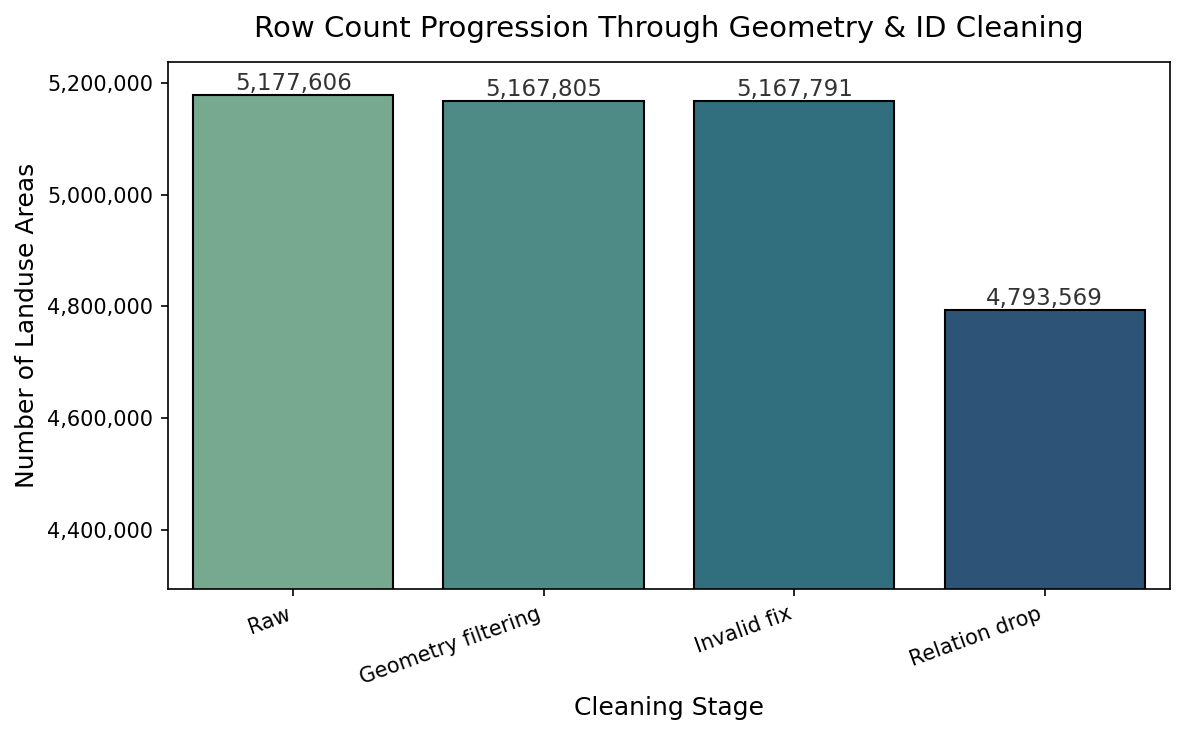

In [17]:
stages = ['Raw', 'Geometry filtering', 'Invalid fix',
    'Relation drop']

counts = [before, after_geo_filtering, after_invalid_fix, len(gdf_poi)]

# Compute zoom range
min_val = min(counts)
max_val = max(counts)

# Add margin for readability
lower = min_val - 500000
upper = max_val + 60000

plt.figure(figsize=(8, 5), dpi=150)

ax = sns.barplot(x=stages, y=counts, palette="crest", edgecolor="black")

plt.title("Row Count Progression Through Geometry & ID Cleaning", fontsize=14, pad=12)
plt.ylabel("Number of Landuse Areas", fontsize=12)
plt.xlabel("Cleaning Stage", fontsize=12)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.ylim(lower, upper)
plt.xticks(rotation=20, ha='right')

# Add labels above bars
for i, c in enumerate(counts):
    ax.text(i, c + (upper - lower) * 0.01, f"{c:,}", ha="center", fontsize=11, color="#333")

plt.tight_layout()
plt.show()


In [18]:
obj_cols = gdf_poi.select_dtypes(include=['object']).columns
print(gdf_poi[obj_cols].isna().sum())   
obj_cols

tags                      1411860
visible                         0
version                         0
id                              0
addr:city                 4319972
addr:country              4510931
addr:full                 4793519
addr:housenumber          4302497
addr:housename            4788844
addr:postcode             4312771
addr:place                4789865
addr:street               4292015
email                     4709051
name                      3615148
opening_hours             4293673
operator                  4268077
phone                     4552857
ref                       4631085
url                       4790640
website                   4490098
amenity                    991754
arts_centre               4793568
atm                       4780592
bank                      4793566
bicycle_parking           4624776
bicycle_rental            4789689
bicycle_repair_station    4793568
bar                       4792169
bbq                       4793275
biergarten    

Index(['tags', 'visible', 'version', 'id', 'addr:city', 'addr:country',
       'addr:full', 'addr:housenumber', 'addr:housename', 'addr:postcode',
       ...
       'tourism', 'viewpoint', 'zoo', 'osm_type', 'driving_school', 'hospital',
       'baby_goods', 'snowmobile', 'chalet', 'picnic_site'],
      dtype='object', length=217)

In [19]:
for col in obj_cols:
    print(f"\nColumn: {col}")
    print(gdf_poi[col].value_counts().head(10))
    print(f"Unique values: {gdf_poi[col].nunique()}")
    print()


Column: tags


tags
{"backrest":"yes"}                      196308
{"access":"private"}                     96363
{"backrest":"yes","material":"wood"}     58032
{"hiking":"yes"}                         49277
{"capacity":"1"}                         36844
{"access":"yes","fee":"no"}              36817
{"access":"customers","fee":"no"}        34359
{"wheelchair":"yes"}                     33541
{"backrest":"no"}                        32948
{"waste":"trash"}                        31025
Name: count, dtype: int64
Unique values: 1011452


Column: visible
visible
False    4793569
Name: count, dtype: int64
Unique values: 1


Column: version
version
1     2257370
2      984397
3      518753
4      331642
5      203094
6      134148
7       93523
8       67591
9       49649
10      36936
Name: count, dtype: int64
Unique values: 89


Column: id
id
1490354705    1
1490331165    1
1490331166    1
1490331167    1
1490331168    1
1490331169    1
1490331170    1
1490331171    1
1490331172    1
1490331157    1
Name

In [20]:
gdf_poi[gdf_poi['tourism']=='hunting_lodge'][['id', 'shop', 'tourism', 'amenity', 'building', 'craft', 'osm_type']].head(10)

,id,shop,tourism,amenity,building,craft,osm_type
412394,1144446201,NaN,hunting_lodge,NaN,NaN,NaN,node
1282132,4580962717,NaN,hunting_lodge,NaN,NaN,NaN,node
1504078,5760641850,NaN,hunting_lodge,NaN,NaN,NaN,node
1703587,6788750026,NaN,hunting_lodge,NaN,NaN,NaN,node
1721058,6873418639,NaN,hunting_lodge,NaN,NaN,NaN,node
1795055,7365447105,NaN,hunting_lodge,NaN,NaN,NaN,node
1934359,8069259514,NaN,hunting_lodge,NaN,NaN,NaN,node
2073223,8809992186,NaN,hunting_lodge,NaN,NaN,NaN,node
2173056,9199466350,NaN,hunting_lodge,NaN,NaN,NaN,node
2348608,9905531445,NaN,hunting_lodge,NaN,NaN,NaN,node


In [21]:
print("Geometry types:")
print(gdf_poi.geom_type.value_counts())

# The key columns for classification
poi_tag_cols = ['amenity', 'craft' ,'shop', 'building', 
                'bank','bureau_de_change', 'post_office', 'restaurant',
    'cafe' , 'bar', 'fast_food', 'pub', 'ice_cream',
    'food_court', 'biergarten', 'bakery',  'brothel',  'cinema' ,
    'gambling','nightclub','car_rental',
    'car_wash','car_repair','bicycle_rental'  ,'travel_agency','hotel' ,
    'hostel','guest_house','arts_centre','library' ,'museum' ,'theatre',
    'zoo','school' ,'driving_school','music_school','university',
    'college','police' ,'social_facility' ,'social_centre',
    'hospital','dentist' ,'doctors','clinic' ,'kindergarten','childcare', 'tourism', 'parking'
]

print("\nCoverage of key classification columns:")
for col in poi_tag_cols:
    if col in gdf_poi.columns:
        n = gdf_poi[col].notna().sum()
        print(f"  {col:<20}: {n:>8,}  ({n/len(gdf_poi):.1%})")

# How many POIs have at least one useful tag?
has_any_tag = gdf_poi[poi_tag_cols].notna().any(axis=1)
print(f"\nPOIs with at least one classification tag: {has_any_tag.sum():,}")
print(f"POIs with NO useful tag                  : {(~has_any_tag).sum():,}")

Geometry types:
Point           3385270
Polygon         1408249
MultiPolygon         50
Name: count, dtype: int64

Coverage of key classification columns:
  amenity             : 3,801,815  (79.3%)


  craft               :    4,698  (0.1%)
  shop                :  400,371  (8.4%)
  building            :    3,415  (0.1%)
  bank                :        3  (0.0%)
  bureau_de_change    :        7  (0.0%)
  post_office         :    3,555  (0.1%)
  restaurant          :      276  (0.0%)
  cafe                :    1,245  (0.0%)
  bar                 :    1,400  (0.0%)
  fast_food           :      551  (0.0%)
  pub                 :       19  (0.0%)
  ice_cream           :      291  (0.0%)
  food_court          :        1  (0.0%)
  biergarten          :      602  (0.0%)
  bakery              :       31  (0.0%)
  brothel             :        2  (0.0%)
  cinema              :        8  (0.0%)
  gambling            :      233  (0.0%)
  nightclub           :        6  (0.0%)
  car_rental          :       18  (0.0%)
  car_wash            :      468  (0.0%)
  car_repair          :       35  (0.0%)
  bicycle_rental      :    3,880  (0.1%)
  travel_agency       :        2  (0.0%)
  hotel         

In [22]:
# ── strategy assignments ────────────────────────────────────
# direct_map = assign L1/L2 from a simple rule (no value lookup needed)
# apply_map  = run apply_building_map() on the raw value

STRATEGY = {
    # apply_map — value determines outcome
    'amenity':            'apply_amenity_map',
    'building':        'apply_building_map',
    'tourism':            'apply_tourism_map',
    'shop':               'apply_shop_map', 
    
    # direct_map — presence (or specific value) is enough
    'bank'                           : ('commercial', 'office'),
    'bureau_de_change'               : ('commercial', 'office'),
    'post_office'                    : ('commercial', 'office'),
    'restaurant'                      : ('commercial', 'food_drink'),
    'cafe'                             : ('commercial', 'food_drink'),
    'bar'                              : ('commercial', 'food_drink'),
    'fast_food'                       : ('commercial', 'food_drink'),
    'pub'                               : ('commercial', 'food_drink'),
    'ice_cream'                       : ('commercial', None),
    'food_court'                      : ('commercial', 'food_drink'),
    'biergarten'                      : ('commercial', 'food_drink'),
    'bakery'                            : ('commercial', 'food_drink'),
    'cinema'                             : ('civic', 'cultural'),
    'gambling'                           : ('civic', 'recreation'),
    'nightclub'                          : ('commercial', 'food_drink'),
    'car_rental'                        : ('commercial', 'office'),
    'car_wash'                          : ('commercial', 'retail'),
    'car_repair'                         : ('commercial', 'retail'),
    'bicycle_rental'                    : ('commercial', 'office'),
    'travel_agency'                      : ('commercial', 'office'),
    'hotel'                             : ('commercial', 'accommodation'),
    'hostel'                            : ('commercial', 'accommodation'),
    'guest_house'                      : ('commercial', 'accommodation'),
    'arts_centre'                        : ('civic', 'cultural'),
    'library'                            : ('civic', 'cultural'),
    'museum'                            : ('civic', 'cultural'),
    'theatre'                           : ('civic', 'cultural'),
    'zoo'                                : ('civic', 'cultural'),
    'school'                            : ('civic', 'school'),
    'driving_school'                    : ('civic', 'school'),
    'music_school'                     : ('civic', 'school'),
    'university'                        : ('civic', 'higher_ed'),
    'college'                           : ('civic', 'higher_ed'),
    'police'                            : ('civic', 'emergency_service'),
    'social_facility'                    : ('civic', 'care_facility'),
    'social_centre'                     : ('civic', 'community'),
    'hospital'                          : ('civic', 'hospital'),
    'dentist'                        : ('civic', 'clinic'),
    'doctors'               : ('civic', 'clinic'),
    'clinic'                : ('civic', 'clinic'),
    'kindergarten'                      : ('civic', 'kindergarten'),
    'childcare'                         : ('civic', 'kindergarten'),
    'parking'                           : ('transportation', 'parking')
}



# Align strategy keys to actual column names in gdf_poi
actual_strategy = {}
for raw_key, strat in STRATEGY.items():
    # try exact match first
    if raw_key in gdf_poi.columns:
        actual_strategy[raw_key] = strat
    


# Report alignment
found = set(actual_strategy.keys())
poi_set = set(poi_tag_cols)
in_strategy_not_df  = {k for k in STRATEGY if k not in poi_set and k not in poi_set}
in_df_not_strategy  = poi_set - found

print(f'Strategy entries aligned to actual columns : {len(actual_strategy)}')
print(f'Strategy keys not found in df              : {len(in_strategy_not_df)}')
if in_strategy_not_df:
    print(f'  {sorted(in_strategy_not_df)}')
print(f'Tag columns in df but not in strategy      : {len(in_df_not_strategy)}')
if in_df_not_strategy:
    print(f'  (these will be skipped during mapping)')
    for c in sorted(in_df_not_strategy):
        print(f'    {c}')


Strategy entries aligned to actual columns : 47
Strategy keys not found in df              : 0
Tag columns in df but not in strategy      : 2
  (these will be skipped during mapping)
    brothel
    craft


In [23]:
# drop the NaNs and remove parking from the list
poi_tag_cols_no_parking = [col for col in poi_tag_cols if col != 'parking']
    
# Count how many poi columns  does a building have
signal_count = gdf_poi[poi_tag_cols_no_parking].notna().sum(axis=1)

print('NUMBER OF POI COLUMNS PER ID:')
print(f'  (considering {len(poi_tag_cols_no_parking)} poi columns)')
sc_counts = signal_count.value_counts().sort_index()
for n_sig, cnt in sc_counts.items():
    bar = '█' * min(60, int(cnt / TOTAL * 200))
    print(f'  {n_sig:>2} tags : {cnt:>10,}  ({cnt/TOTAL*100:.2f}%)  {bar}')
print()
print(f'IDs with >= 2 simultaneous tags: '
      f'{(signal_count >= 2).sum():,}  ({(signal_count >= 2).sum()/TOTAL*100:.2f}%)')
print(f'Buildings with >= 3 simultaneous tags: '
      f'{(signal_count >= 3).sum():,}  ({(signal_count >= 3).sum()/TOTAL*100:.2f}%)')


NUMBER OF POI COLUMNS PER ID:
  (considering 48 poi columns)
   0 tags :          1  (0.00%)  
   1 tags :  4,739,949  (91.72%)  ████████████████████████████████████████████████████████████
   2 tags :     51,908  (1.00%)  ██
   3 tags :      1,638  (0.03%)  
   4 tags :         70  (0.00%)  
   5 tags :          3  (0.00%)  

IDs with >= 2 simultaneous tags: 53,619  (1.04%)
Buildings with >= 3 simultaneous tags: 1,711  (0.03%)


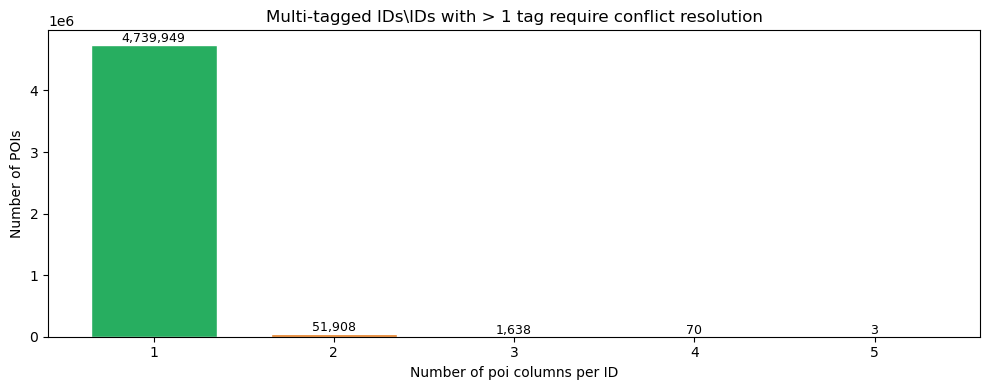

In [24]:
# ── Plot: signal count distribution ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sc_plot = sc_counts[sc_counts.index > 0]  # exclude 0-signal buildings
ax.bar(sc_plot.index.astype(str), sc_plot.values,
       color=['#27ae60','#e67e22','#e74c3c','#9b59b6','#3498db'][:len(sc_plot)],
       edgecolor='white', width=0.7)
for x, y in zip(sc_plot.index.astype(str), sc_plot.values):
    ax.text(x, y + max(sc_plot.values)*0.01, f'{y:,}', ha='center', fontsize=9)
ax.set_xlabel('Number of poi columns per ID')
ax.set_ylabel('Number of POIs')
ax.set_title('Multi-tagged IDs\IDs with > 1 tag require conflict resolution')
plt.tight_layout(); plt.show()


In [25]:
# Filter the dataframe for buildings with more 2 signals
two_tags_df = gdf_poi[signal_count >= 2]

print(f"Total POIs with exactly 2 tags: {len(two_tags_df):,}\n")
print("SAMPLE OF 10 POIs AND THEIR SPECIFIC TAGS:")
print("-" * 60)

sample_size = min(20, len(two_tags_df))
sample_df = two_tags_df.sample(sample_size)

# Iterate through the sample and print only the non-null columns
for idx, row in sample_df.iterrows():
    active_tags = row[poi_tag_cols_no_parking].dropna()
    
    print(f"POI Index/ID: {idx}")
    for col_name, val in active_tags.items():
        print(f"  • {col_name}: '{val}'")
    print()

Total POIs with exactly 2 tags: 53,619

SAMPLE OF 10 POIs AND THEIR SPECIFIC TAGS:
------------------------------------------------------------
POI Index/ID: 391197
  • shop: 'bakery'
  • cafe: 'yes'

POI Index/ID: 3284624
  • amenity: 'bar'
  • shop: 'clothes'

POI Index/ID: 3012547
  • shop: 'beverages'
  • post_office: 'post_partner'

POI Index/ID: 2032130
  • shop: 'optician'
  • building: 'yes'

POI Index/ID: 1899103
  • amenity: 'bicycle_rental'
  • bicycle_rental: 'docking_station'

POI Index/ID: 2038558
  • amenity: 'waste_basket'
  • tourism: 'information'

POI Index/ID: 444610
  • amenity: 'restaurant'
  • tourism: 'hotel'

POI Index/ID: 1817985
  • amenity: 'social_facility'
  • social_facility: 'ambulatory_care'

POI Index/ID: 2474254
  • amenity: 'social_facility'
  • social_facility: 'outreach'

POI Index/ID: 1505811
  • amenity: 'cafe'
  • bar: 'no'

POI Index/ID: 559412
  • amenity: 'post_office'
  • shop: 'stationery'

POI Index/ID: 46301
  • amenity: 'cafe'
  • shop: 

In [26]:
# Get the buildings with >= 2 signals
multi_df = gdf_poi[signal_count >= 2][poi_tag_cols]

# Convert to a boolean matrix (1 if tag is present, 0 if empty)
bool_df = multi_df.notna().astype(int)

# Matrix multiplication calculates the co-occurrence of every column instantly
print("Calculating co-occurrence matrix...")
co_occ_matrix = bool_df.T.dot(bool_df)

# Mask the matrix to avoid counting the diagonal (A co-occurring with A) 
# and the lower triangle (avoiding duplicate A-B and B-A pairs)
mask = np.triu(np.ones(co_occ_matrix.shape), k=1).astype(bool)
pairs = co_occ_matrix.where(mask).stack()

# Sort to find the most frequent pairs
top_pairs = pairs.sort_values(ascending=False).head(50)

print("\nTOP 50 MOST FREQUENTLY CO-OCCURRING TAG PAIRS:")
print("-" * 85)
print(f"{'Tag A':<35} | {'Tag B':<35} | {'Co-occurrences':>12}")
print("-" * 85)

for (poi_a, poi_b), count in top_pairs.items():
    if count > 0:
        print(f"{poi_a:<35} | {poi_b:<35} | {int(count):>12,}")

Calculating co-occurrence matrix...

TOP 50 MOST FREQUENTLY CO-OCCURRING TAG PAIRS:
-------------------------------------------------------------------------------------
Tag A                               | Tag B                               | Co-occurrences
-------------------------------------------------------------------------------------
amenity                             | social_facility                     |       13,195
amenity                             | tourism                             |        8,900
amenity                             | shop                                |        7,423
craft                               | shop                                |        4,045
amenity                             | bicycle_rental                      |        3,870
shop                                | post_office                         |        2,791
amenity                             | building                            |        2,574
museum                        

In [27]:
import importlib
import building_map
import amenity_map
import shop_map

importlib.reload(building_map)
importlib.reload(amenity_map)
importlib.reload(shop_map)

from building_map import apply_building_map
from amenity_map import apply_amenity_map
from shop_map import apply_shop_map




In [28]:
gdf_bldg[gdf_bldg['building:use']=='recycling'][['id', 'shop', 'amenity', 'building']].head(10)

,id,shop,amenity,building
18277458,330236996,None,None,industrial


In [29]:
gdf_poi[gdf_poi['building'].notna()][['id', 'shop', 'restaurant', 'amenity', 'building', 'osm_type']].sample(10)

,id,shop,restaurant,amenity,building,osm_type
1807322,7429209080,NaN,NaN,shelter,roof,node
161999,443718191,clothes,NaN,NaN,yes,node
3351797,13506311556,farm,NaN,NaN,hut,node
2239597,9510649741,NaN,NaN,townhall,house,node
1121894,3913859132,NaN,NaN,place_of_worship,chapel,node
871573,2836958242,NaN,NaN,place_of_worship,wayside_shrine,node
67743,312952818,NaN,NaN,kindergarten,yes,node
3213537,13062309808,NaN,NaN,parking,garage,node
3379331,13634688587,NaN,NaN,social_facility,apartments,node
3893905,way_320102448,NaN,NaN,place_of_worship,church,way


In [30]:
TOURISM_MAP = {
    'hotel'         : ('commercial', 'accommodation'),
    'hostel'        : ('commercial', 'accommodation'),
    'guest_house'   : ('commercial', 'accommodation'),
    'apartment'     : ('commercial', 'accommodation'),
    'chalet'     : ('commercial', 'accommodation'),
    'alpine_hut'     : ('commercial', 'accommodation'),
    'motel'     : ('commercial', 'accommodation'),
    'guest_house;apartment'     : ('commercial', 'accommodation'),
    'hunting_lodge'     : ('commercial', 'accommodation'),
    'apartment;guest_house'     : ('commercial', 'accommodation'),
    'museum'        : ('civic', 'cultural'),
    'gallery'       : ('civic', 'cultural'),
    'zoo'           : ('civic', 'cultural'),
    'theme_park'    : ('civic', 'recreation'),
    'aquarium'    : ('civic', 'recreation'),
}

# Normalise map once at module load — handles mixed-case keys in TAG_MAP
_TOURISM_MAP_NORM: dict = {
    re.sub(r'\s+', ' ', k.strip().lower()): v
    for k, v in TOURISM_MAP.items()
}


def _normalize(value) -> str:
    """Lowercase, collapse whitespace, strip trailing semicolons."""
    s = str(value).strip().lower()
    return re.sub(r'\s+', ' ', s).rstrip(';')


def apply_tourism_map(use_value) -> tuple:
    
    if pd.isna(use_value):
        return (None, None)

    s = _normalize(use_value)

    #  Direct lookup
    if s in _TOURISM_MAP_NORM:
        return _TOURISM_MAP_NORM[s]

    # Unmappable
    return (None, None)


In [31]:
print("Evaluating exact L1 and L2 categories for conflicts...\n")

detailed_conflicts = []

for idx, row in multi_df.iterrows():
    # Store unique combinations of (L1, L2)
    mapped_categories = set()
    evidence = []
    
    for col in poi_tag_cols_no_parking:
        val = row[col]
        if pd.notna(val) and val != '':
            strat = actual_strategy.get(col)
            l1, l2 = None, None
            
            # Extract L1 and L2 based on the strategy
            if strat == 'apply_amenity_map':
                res = apply_amenity_map(val)
                if res and res[0]: 
                    l1, l2 = res[0], res[1]
            elif strat == 'apply_building_map':
                res = apply_building_map(val)
                if res and res[0]: 
                    l1, l2 = res[0], res[1]
            elif strat == 'apply_shop_map':
                res = apply_shop_map(val)
                if res and res[0]: 
                    l1, l2 = res[0], res[1]
            elif isinstance(strat, tuple):
                l1, l2 = strat[0], strat[1]
            elif strat == 'apply_tourism_map':
                res = apply_tourism_map(val)
                if res and res[0]: 
                    l1, l2 = res[0], res[1]
            
            if l1 and l1 != 'filter':
                # Handle cases where L2 might be missing/None
                l2_str = l2 if pd.notna(l2) and l2 else "unspecified"
                mapped_categories.add((l1, l2_str))
                evidence.append(f"{col}='{val}' → {l1}({l2_str})")
                
    # If the building resolves to more than one distinct (L1, L2) pair
    if len(mapped_categories) > 1:
        # Check if L1s are different, or just L2s
        l1s = set([cat[0] for cat in mapped_categories])
        c_type = "L1 Conflict (Major)" if len(l1s) > 1 else "L2 Conflict (Minor)"
        
        # Format the clash nicely: e.g., "commercial(retail) vs residential(apartments)"
        clash_str = " vs ".join(sorted([f"{c[0]}({c[1]})" for c in mapped_categories]))
        
        detailed_conflicts.append({
            'building_idx': idx,
            'conflict_type': c_type,
            'clash': clash_str,
            'evidence': " | ".join(evidence)
        })

df_conflicts = pd.DataFrame(detailed_conflicts)

if not df_conflicts.empty:
    print("=====================================================================")
    print(f"MAJOR CONFLICTS (Different L1 Categories): {(df_conflicts['conflict_type'] == 'L1 Conflict (Major)').sum():,}")
    print("=====================================================================")
    print(df_conflicts[df_conflicts['conflict_type'] == 'L1 Conflict (Major)']['clash'].value_counts().head(10))
    
    print("\n=====================================================================")
    print(f"MINOR CONFLICTS (Same L1, Different L2 Subcategories): {(df_conflicts['conflict_type'] == 'L2 Conflict (Minor)').sum():,}")
    print("=====================================================================")
    print(df_conflicts[df_conflicts['conflict_type'] == 'L2 Conflict (Minor)']['clash'].value_counts().head(10))
    
    print("\nSAMPLE OF 5 ACTUAL POIS CAUSING MAJOR CONFLICTS:")
    with pd.option_context('display.max_colwidth', None):
        display(df_conflicts[df_conflicts['conflict_type'] == 'L1 Conflict (Major)'][['clash', 'evidence']].sample(min(25, len(df_conflicts))))
else:
    print("No conflicts found!")

Evaluating exact L1 and L2 categories for conflicts...



MAJOR CONFLICTS (Different L1 Categories): 843
clash
civic(cultural) vs commercial(retail)            248
civic(care_facility) vs commercial(retail)        94
commercial(accommodation) vs residential(SFH)     81
civic(recreation) vs commercial(retail)           36
civic(school) vs commercial(retail)               34
civic(community) vs commercial(accommodation)     26
civic(clinic) vs commercial(retail)               22
civic(recreation) vs commercial(food_drink)       21
civic(cultural) vs commercial(food_drink)         18
civic(community) vs commercial(retail)            15
Name: count, dtype: int64

MINOR CONFLICTS (Same L1, Different L2 Subcategories): 9,783
clash
commercial(accommodation) vs commercial(food_drink)                          3601
commercial(office) vs commercial(retail)                                     3401
commercial(food_drink) vs commercial(retail)                                 1634
commercial(office) vs commercial(other_service)                              

,clash,evidence
4796,civic(cultural) vs commercial(retail),shop='art' → commercial(retail) | tourism='gallery' → civic(cultural)
7758,civic(community) vs commercial(food_drink),amenity='events_venue' → civic(community) | bar='yes' → commercial(food_drink)
4728,civic(community) vs commercial(office),amenity='funeral_hall' → civic(community) | shop='funeral_directors' → commercial(office)
10610,civic(care_facility) vs commercial(unspecified),amenity='social_facility' → civic(care_facility) | building='commercial' → commercial(unspecified) | social_facility='outreach' → civic(care_facility)
7215,civic(care_facility) vs commercial(retail),amenity='social_facility' → civic(care_facility) | shop='clothes' → commercial(retail) | social_facility='clothing_bank' → civic(care_facility)
5287,civic(cultural) vs commercial(retail),shop='art' → commercial(retail) | tourism='gallery' → civic(cultural)
4776,civic(recreation) vs commercial(food_drink),amenity='pub' → commercial(food_drink) | gambling='slot_machines' → civic(recreation)
10464,civic(school) vs commercial(accommodation),amenity='school' → civic(school) | tourism='hostel' → commercial(accommodation)
8821,agricultural(unspecified) vs commercial(accommodation),building='farm' → agricultural(unspecified) | tourism='apartment' → commercial(accommodation)
9722,commercial(retail) vs residential(MFH),shop='bicycle' → commercial(retail) | building='apartments' → residential(MFH)


In [32]:
# Filter to buildings with >= 2 signals
multi_mask = signal_count >= 2.
multi_df   = gdf_poi[multi_mask].copy() # Keep all columns so we have OSM IDs if needed

print(f'Evaluating {len(multi_df):,} multi-signal buildings for exact conflicts...\n')

actual_conflicts = []

# Iterate through multi-signal buildings
for idx, row in multi_df.iterrows():
    building_l1s = set()
    poi_details = []
    
    # Check every non-filter column for this specific building
    for col in poi_tag_cols_no_parking:
        val = row[col]
        if pd.notna(val) and val != '':
            
            # Find the exact L1 for this specific value
            strat = actual_strategy.get(col)
            l1 = None
            
            # Extract L1 and L2 based on the strategy
            if strat == 'apply_amenity_map':
                res = apply_amenity_map(val)
                if res and res[0]: 
                    l1, l2 = res[0], res[1]

            
            elif strat == 'apply_shop_map':
                res = apply_shop_map(val)
                if res and res[0]: 
                    l1, l2 = res[0], res[1]

            elif strat == 'apply_building_map':
                res = apply_building_map(val)
                if res and res[0]: 
                    l1, l2 = res[0], res[1]
            
            elif isinstance(strat, tuple):
                l1, l2 = strat[0], strat[1]
            elif strat == 'apply_tourism_map':
                res = apply_tourism_map(val)
                if res and res[0]: 
                    l1, l2 = res[0], res[1]
            
            # If it yielded a valid L1, record it
            if l1 and l1 != 'filter':
                building_l1s.add(l1)
                poi_details.append(f"{col}='{val}' → {l1}")
                
    # If this single building resolves to MORE THAN ONE distinct L1 category, it's a true conflict with the building id

    if len(building_l1s) > 1:
        actual_conflicts.append({
            'building_idx': idx,
            'conflict_l1s': " vs ".join(sorted(building_l1s)),
            'poi_evidence': " | ".join(poi_details)
        })

# Convert results to a DataFrame for easy viewing
conflicts_df = pd.DataFrame(actual_conflicts)

print(f"Found {len(conflicts_df):,} buildings with GENUINE L1 conflicts.")
print("-" * 80)

if not conflicts_df.empty:
    # Show how many times each specific L1 clash happens
    print("\nMOST COMMON EXACT L1 CLASHES:")
    print(conflicts_df['conflict_l1s'].value_counts().head(10))
    
    print("\nSAMPLE OF 10 ACTUAL CONFLICTING BUILDINGS:")
    # Set pandas display options temporarily to show the full text
    with pd.option_context('display.max_colwidth', None):
        display(conflicts_df[['conflict_l1s', 'poi_evidence']].sample(min(10, len(conflicts_df))))

Evaluating 53,619 multi-signal buildings for exact conflicts...

Found 843 buildings with GENUINE L1 conflicts.
--------------------------------------------------------------------------------

MOST COMMON EXACT L1 CLASHES:
conflict_l1s
civic vs commercial             635
commercial vs residential       139
civic vs residential             24
agricultural vs commercial       22
commercial vs industrial          7
agricultural vs civic             6
civic vs military                 4
agricultural vs residential       2
civic vs industrial               2
commercial vs transportation      2
Name: count, dtype: int64

SAMPLE OF 10 ACTUAL CONFLICTING BUILDINGS:


,conflict_l1s,poi_evidence
556,civic vs residential,amenity='social_facility' → civic | building='house' → residential | social_facility='assisted_living' → civic
827,civic vs commercial,amenity='school' → civic | tourism='hostel' → commercial
212,civic vs commercial,amenity='events_venue' → civic | tourism='apartment' → commercial
141,civic vs commercial,amenity='cinema' → civic | shop='erotic' → commercial
195,civic vs commercial,amenity='casino' → civic | hotel='yes' → commercial
55,civic vs commercial,shop='motorcycle' → commercial | tourism='museum' → civic
227,civic vs commercial,shop='art' → commercial | tourism='gallery' → civic
693,civic vs commercial,amenity='social_facility' → civic | shop='clothes' → commercial | social_facility='clothing_bank' → civic
323,civic vs commercial,shop='art' → commercial | tourism='gallery' → civic
45,civic vs commercial,amenity='events_venue' → civic | tourism='guest_house' → commercial


In [33]:
# ── Source confidence (higher = more trusted) ─────────────────────────

CONFIDENCE = {
    # High-Priority Institutions (Health, Education, Civic)
    'hospital':         10,
    'clinic':           10,
    'doctors':          10,
    'dentist':          10,
    'police':           10,
    'school':           10,
    'university':       10,
    'college':          10,
    'kindergarten':     10,
    'childcare':        10,
    'amenity':          11,
    'shop':             6,
    'building':         7,
    
    # Culture, Lodging & Major Entertainment
    'museum':           9,
    'library':          9,
    'theatre':          9,
    'cinema':           9,
    'zoo':              6,
    'hotel':            9,
    'hostel':           9,
    'guest_house':      9,
    'nightclub':        8,
    'brothel':          8,
    'gambling':         8,
    'bank':             8,
    'post_office':      8,
    
    # Food & Drink
    'restaurant':       7,
    'fast_food':        7,
    'cafe':             7,
    'pub':              7,
    'bar':              7,
    'biergarten':       7,
    'food_court':       7,
    'bakery':           7,
    'ice_cream':        5,
    
    # Retail, Services & Transport
    'car_repair':       8,
    'car_wash':         8,
    'car_rental':       8,
    'bicycle_rental':   8,
    'travel_agency':    8,
    'bureau_de_change': 8,
    'driving_school':   8,
    'music_school':     8,

    # Broad Categories & Facilities
    'social_facility':  8,
    'social_centre':    7,
    'arts_centre':      8,

    # Accessory / Generic Tags
    'parking':          2,
    'tourism': 3,
}

DEFAULT_CONFIDENCE = 3

In [34]:
# ── Override raw tags for cleaner output ──────────────────────────
TAG_USED_OVERRIDES = ['amenity', 'shop', 'building', 'tourism']

def extract_candidates(row):
    """
    Given a single building row, return a list of candidate dicts.
    Each dict: {l1, l2, source, tag, confidence,}
    """
    candidates = []

    for col in poi_tag_cols:
        val = row.get(col)
        if pd.isna(val) or val == '' or val is None or str(val).strip().lower() == 'no':
            continue
        val_str = str(val).strip().lower()
        strat   = STRATEGY.get(col)
        conf    = CONFIDENCE.get(col, DEFAULT_CONFIDENCE)
        
        l1, l2 = None, None

        # ── apply_map ─────────────────────────────────────────────────
        if strat == 'apply_amenity_map':
            result = apply_amenity_map(val_str)
            if result:
                l1, l2 = result[0], result[1]

                
        elif strat == 'apply_shop_map':
            result = apply_shop_map(val_str)
            if result:
                l1, l2 = result[0], result[1]
        
        elif strat == 'apply_building_map':
            result = apply_building_map(val_str)
            if result:
                l1, l2 = result[0], result[1]
            
        # ── direct_map ───────────────────────────────────────────────
        elif isinstance(strat, tuple):
            l1, l2 = strat[0], strat[1] 

            # Special overrides for direct_map cols 
            if col == 'bicycle_rental':
                if val_str not in ('shop', 'institutional'):
                    l1, l2 = None, None
                
            if col == 'parking':
                if val_str not in ('multi-storey',):
                    l1, l2 = None, None

            if col == 'police':
                if val_str in ('academy',):
                    l2 = 'school'
             
        elif strat == 'apply_tourism_map':
            result = apply_tourism_map(col)
            if result:
                l1, l2 = result[0], result[1]      

        
        if l1 is None: 
            continue

        # Look up if this column has a hardcoded override, otherwise use val_str
        display_tag = col if col not in TAG_USED_OVERRIDES else val_str

        candidates.append({
            'l1':         l1,
            'l2':         l2,
            'source':     col,
            'tag':        display_tag,  
            'confidence': conf,
        })

    return candidates

# quick sanity test
row0 = gdf_poi.iloc[0]
cands= extract_candidates(row0)
print(f'Sample row 0 — {len(cands)} candidate(s)')
for c in cands:
    print(f'  {c["source"]:40s}  {c["l1"]:15s} / {str(c["l2"]):20s}  conf={c["confidence"]}')


Sample row 0 — 0 candidate(s)


In [35]:
# ── L1 priority (lower index = higher priority) ───────────────────────
L1_PRIORITY: list[str] = [
   'military', 'industrial',  'civic', 'transportation', 'semi_commercial', 'commercial', 
   'residential', 'agricultural', 'filter'
]

def l1_rank(l1):
    try:
        return L1_PRIORITY.index(l1)
    except ValueError:
        return 99
    
def resolve_l2(candidates):
    """Resolve L2: merge if all commercial, else pick highest-confidence.
    1. Drop None L2s if any concrete L2 exists
    2. If all concrete L2s are the same → return it directly (no conflict)
    3. If different → pick highest confidence winner
    4. If confidence tie → return None (genuine ambiguity)"""
    # Remove None / 'unspecified' if a concrete L2 exists
    concrete = [c for c in candidates if c['l2'] is not None]
    
    if not concrete:
        return None

    unique_l2s = set(c['l2'] for c in concrete)

    # Step 2: all agree → no conflict, return immediately
    if len(unique_l2s) == 1:
        return concrete[0]['l2']
    
    # Different L2s → highest confidence wins
    max_conf = max(c['confidence'] for c in concrete)
    top = [c for c in concrete if c['confidence'] == max_conf]

    # Genuine tie → ambiguity
    if len(top) == 1:
        return top[0]['l2']
    
       
    return top[0]['l2']

def make_semi_commercial_l2(l1_set, candidates):
    """
    When residential + commercial coexist, build a semi_commercial L2.
    E.g.  residential + retail  →  residential_retail
          residential + office  →  residential_office
          residential + None    →  residential_commercial
    """
    com_candidates = [c for c in candidates if c['l1'] == 'commercial']

    if 'residential' in l1_set and 'commercial' in l1_set:
        com_sub = resolve_l2(com_candidates) or 'commercial'
        return f'residential_{com_sub}'
    return f'residential_{com_sub}'
    

def resolve_candidates(candidates):
    """
    Input : list of candidate dicts from extract_candidates()
    Output: dict with keys:
        poi_l1, poi_l2, is_semi_commercial,
        poi_source, poi_used, all_candidates
    """
    
    result = dict(
        poi_l1=None, poi_l2=None, is_semi_commercial=False,
        poi_source=None, poi_used=None,
        all_candidates=str([(c['source'], c['l1'], c['l2']) for c in candidates])
    )

    # ── CASE 0: nothing ───────────────────────────────────────────────
    if not candidates:
        return result

    # ── CASE 1: single candidate ──────────────────────────────────────
    if len(candidates) == 1:
        c = candidates[0]
        result.update(poi_l1=c['l1'], poi_l2=c['l2'],
                      poi_source=c['source'], poi_used=c['tag'])
        return result


    # ── helper: join all contributing sources ─────────────────────────
    def all_sources(cands):
        return '+'.join(sorted(set(c['source'] for c in cands)))

    l1_set = set(c['l1'] for c in candidates)


    # ── CASE 2: all same L1 ───────────────────────────────────────────
    if len(l1_set) == 1:
        best_l2  = resolve_l2(candidates)
        best_src = max(candidates, key=lambda c: (c['confidence'],  c['source']))
        result.update(poi_l1=list(l1_set)[0], poi_l2=best_l2,
                      poi_source=all_sources(candidates), poi_used=best_src['tag'])
        return result

    # ── CASE 3: SEMI-COMMERCIAL ───────────────────────────────────────
    SEMI_PAIRS = [{'residential', 'commercial'}, {'residential', 'civic'}]

    for pair in SEMI_PAIRS:
        if pair.issubset(l1_set):
            semi_l2 = make_semi_commercial_l2(l1_set, candidates)
            
            contributing_sources = sorted(set(c['source'] for c in candidates))
            best_src = max(candidates, key=lambda c: (c['confidence'], c['source']))
            
            result.update(
                poi_l1='semi_commercial', poi_l2=semi_l2,
                is_semi_commercial=True,
                poi_source=all_sources(candidates),  
                poi_used=best_src['tag']
            )
            return result
        
    
    # ── CASE 4: MAJOR CONFLICT — Confidence FIRST, then priority ladder ──
    # Find the highest confidence score among all candidates
    max_conf = max(c['confidence'] for c in candidates)
    
    # Filter to only the candidates that share this highest score
    top_candidates = [c for c in candidates if c['confidence'] == max_conf]
    
    # If there is still a tie in confidence, use the Priority Ladder
    top_l1_set = set(c['l1'] for c in top_candidates)
    best_l1 = min(top_l1_set, key=l1_rank)
    
    # Extract the winning L2 and source from the victors
    winning = [c for c in top_candidates if c['l1'] == best_l1]
    best_l2  = resolve_l2(winning)
    best_src = max(winning, key=lambda c: (c['confidence'],  c['source']))
    
    result.update(poi_l1=best_l1, poi_l2=best_l2,
                  poi_source=best_src['source'], poi_used=best_src['tag'])
    return result


print('resolve_candidates() defined')

resolve_candidates() defined


In [36]:
from tqdm.auto import tqdm
import time

print("1. Filtering out empty pois...")
start_time = time.time()
# Only process buildings that actually have at least one tag (saves massive time)
has_tags_mask = gdf_poi[poi_tag_cols].notna().any(axis=1)
df_to_process = gdf_poi[has_tags_mask][poi_tag_cols + ['id']]

print(f"  → Found {len(df_to_process):,} pois with tags to classify.")

print("2. Converting to dictionary records for high-speed processing...")
records = df_to_process.to_dict('records')

print("3. Classifying pois...")
results_list = []

for row in tqdm(records, desc="Processing"):
    candidates = extract_candidates(row)
    resolution = resolve_candidates(candidates)
    resolution['id'] = row['id']
    results_list.append(resolution)

print("4. Merging results back to main dataset...")
results_df = pd.DataFrame(results_list)

# Drop old classification columns if they exist so we don't get duplicates (_x, _y)
cols_to_drop = [c for c in results_df.columns if c in gdf_poi.columns and c != 'id']
if cols_to_drop:
    gdf_poi = gdf_poi.drop(columns=cols_to_drop)

# Merge back into the main 38M row dataframe
gdf_poi = gdf_poi.merge(results_df, on='id', how='left')

# Fill empty buildings with default values
gdf_poi['is_semi_commercial'] = gdf_poi['is_semi_commercial'].fillna(False)

print(f"Done in {time.time() - start_time:.1f} seconds!")


1. Filtering out empty pois...


/fast/home/o-olajuyigbe/miniforge3/envs/osm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  → Found 4,793,568 pois with tags to classify.
2. Converting to dictionary records for high-speed processing...
3. Classifying pois...


Processing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 4793568/4793568 [03:55<00:00, 20387.20it/s]


4. Merging results back to main dataset...
Done in 501.5 seconds!


/tmp/ipykernel_1473858/2980869627.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gdf_poi['is_semi_commercial'] = gdf_poi['is_semi_commercial'].fillna(False)


--- Classification Summary ---


Total POIs with an L1 classification: 3,318,270
Total mixed-use (semi-commercial) buildings: 41



/tmp/ipykernel_1473858/3077074664.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=l1_counts.values, y=l1_counts.index, palette="viridis")


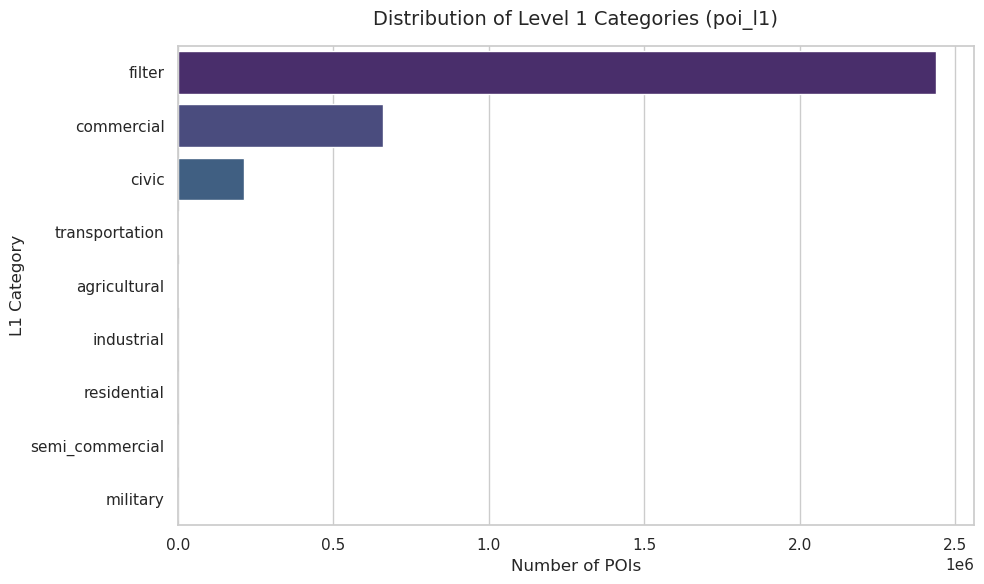

/tmp/ipykernel_1473858/3077074664.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=l2_counts.values, y=l2_counts.index, palette="magma")


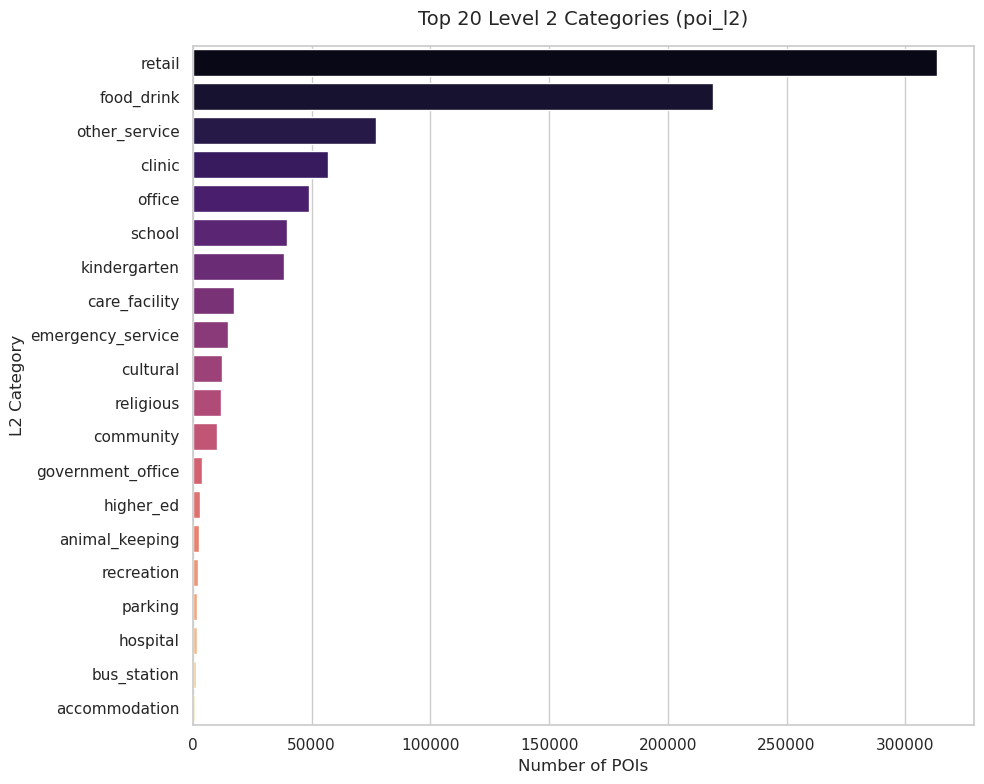

In [37]:
# Set a clean visual style
sns.set_theme(style="whitegrid")

print("--- Classification Summary ---")
classified_count = gdf_poi['poi_l1'].notna().sum()
mixed_use_count = gdf_poi['is_semi_commercial'].sum()

print(f"Total POIs with an L1 classification: {classified_count:,}")
print(f"Total mixed-use (semi-commercial) buildings: {mixed_use_count:,}\n")

# ── Plot Level 1 Distribution ──────────────────────────────────────
plt.figure(figsize=(10, 6))

# Count values and drop the Nones/NaNs just for plotting
l1_counts = gdf_poi['poi_l1'].value_counts()

# Create a horizontal bar chart
sns.barplot(x=l1_counts.values, y=l1_counts.index, palette="viridis")

plt.title("Distribution of Level 1 Categories (poi_l1)", fontsize=14, pad=15)
plt.xlabel("Number of POIs", fontsize=12)
plt.ylabel("L1 Category", fontsize=12)
plt.tight_layout()
plt.show()


# ── Plot Top 20 Level 2 Categories ─────────────────────────────────
plt.figure(figsize=(10, 8))

# Get the top 20 L2 categories
l2_counts = gdf_poi['poi_l2'].value_counts().head(20)

sns.barplot(x=l2_counts.values, y=l2_counts.index, palette="magma")

plt.title("Top 20 Level 2 Categories (poi_l2)", fontsize=14, pad=15)
plt.xlabel("Number of POIs", fontsize=12)
plt.ylabel("L2 Category", fontsize=12)
plt.tight_layout()
plt.show()

In [38]:
# ── Coverage summary ─────────────────────────────────────────────────
classified   = gdf_poi['poi_l1'].notna().sum()
unclassified = TOTAL - classified
filter_count = (gdf_poi['poi_l1'] == 'filter').sum()

print('═'*52)
print(f'  Total buildings        : {TOTAL:>10,}')
print(f'  Classified             : {classified:>10,}  ({classified/TOTAL*100:.1f}%)')
print(f'  Unclassified (no tag)  : {unclassified:>10,}  ({unclassified/TOTAL*100:.1f}%)')
print(f'  Filter structures      : {filter_count:>10,}  ({filter_count/TOTAL*100:.1f}%)')
print(f'  Semi-commercial        : {gdf_poi["is_semi_commercial"].sum():>10,}')
print('═'*52)
print()
print('L1 distribution:')
print(gdf_poi['poi_l1'].value_counts(dropna=False).to_string())
print(gdf_poi['poi_l2'].value_counts(dropna=False).to_string())


════════════════════════════════════════════════════
  Total buildings        :  5,167,791
  Classified             :  3,318,270  (64.2%)
  Unclassified (no tag)  :  1,849,521  (35.8%)
  Filter structures      :  2,438,502  (47.2%)
  Semi-commercial        :         41
════════════════════════════════════════════════════

L1 distribution:
poi_l1
filter             2438502
None               1475298
commercial          659749
civic               211725
transportation        4616
agricultural          3281
industrial             234
residential            112
semi_commercial         41
military                10
NaN                      1
poi_l2
None                         3915970
retail                        313288
food_drink                    218903
other_service                  77128
clinic                         57013
office                         49054
school                         39618
kindergarten                   38267
care_facility                  17147
emergency_servi

In [43]:
# ── Spot-check: sample buildings per L1 for manual review ────────────
SHOW = ['id', 'poi_l1', 'poi_l2', 'is_semi_commercial',
        'poi_source', 'poi_used', 'all_candidates']

for l1 in ['residential', 'commercial', 'civic', 'industrial',
           'semi_commercial', 'military', 'agricultural']:
    sub = gdf_poi[gdf_poi['poi_l1'] == l1]
    if len(sub) == 0:
        continue
    print(f'\n── {l1.upper()}  (n={len(sub):,}) ──────────────────────────────')
    with pd.option_context('display.max_colwidth', 70):
        display(sub[SHOW].sample(min(5, len(sub))))



── RESIDENTIAL  (n=112) ──────────────────────────────


,id,poi_l1,poi_l2,is_semi_commercial,poi_source,poi_used,all_candidates
3219769,13074551477,residential,SFH,False,building,bungalow,"[('building', 'residential', 'SFH')]"
3219749,13074551457,residential,SFH,False,building,bungalow,"[('building', 'residential', 'SFH')]"
2327336,9843914318,residential,SFH,False,building,cabin,"[('building', 'residential', 'SFH')]"
538668,1559883627,residential,SFH,False,amenity,rectory,"[('amenity', 'residential', 'SFH')]"
3219717,13074551425,residential,SFH,False,building,bungalow,"[('building', 'residential', 'SFH')]"



── COMMERCIAL  (n=659,749) ──────────────────────────────


,id,poi_l1,poi_l2,is_semi_commercial,poi_source,poi_used,all_candidates
980745,3342024881,commercial,retail,False,amenity,pharmacy,"[('amenity', 'commercial', 'retail')]"
269635,684632209,commercial,retail,False,shop,beverages,"[('shop', 'commercial', 'retail')]"
2157718,9139784818,commercial,retail,False,shop,furniture,"[('shop', 'commercial', 'retail')]"
698535,2134700232,commercial,food_drink,False,amenity,restaurant,"[('amenity', 'commercial', 'food_drink')]"
2420008,10128649853,commercial,retail,False,shop,sewing,"[('shop', 'commercial', 'retail')]"



── CIVIC  (n=211,725) ──────────────────────────────


...

,id,poi_l1,poi_l2,is_semi_commercial,poi_source,poi_used,all_candidates
1121251,3912414439,semi_commercial,residential_other_service,True,building+shop,house,"[('shop', 'commercial', 'other_service'), ('building', 'residentia..."
2702210,11383415384,semi_commercial,residential_other_service,True,building+shop,residential,"[('shop', 'commercial', 'other_service'), ('building', 'residentia..."
1856056,7683029788,semi_commercial,residential_food_drink,True,amenity+building,biergarten,"[('amenity', 'commercial', 'food_drink'), ('building', 'residentia..."
3662491,way_318441846,semi_commercial,residential_retail,True,building+shop,house,"[('shop', 'commercial', 'retail'), ('building', 'residential', None)]"
1937436,8085684432,semi_commercial,residential_office,True,amenity+building,bank,"[('amenity', 'commercial', 'office'), ('building', 'residential', ..."



── MILITARY  (n=10) ──────────────────────────────


,id,poi_l1,poi_l2,is_semi_commercial,poi_source,poi_used,all_candidates
3503216,135782286,military,bunker,False,building,bunker,"[('building', 'military', 'bunker')]"
1718537,6855642245,military,bunker,False,building,bunker,"[('building', 'military', 'bunker')]"
10948,248664821,military,bunker,False,building,bunker,"[('building', 'military', 'bunker')]"
286370,715896618,military,bunker,False,building,bunker,"[('building', 'military', 'bunker')]"
35253,282661908,military,bunker,False,building,bunker,"[('building', 'military', 'bunker')]"



── AGRICULTURAL  (n=3,281) ──────────────────────────────


,id,poi_l1,poi_l2,is_semi_commercial,poi_source,poi_used,all_candidates
1942830,8119396093,agricultural,animal_keeping,False,amenity,feeding_place,"[('amenity', 'agricultural', 'animal_keeping')]"
4198490,1145294926,agricultural,animal_keeping,False,amenity,feeding_place,"[('amenity', 'agricultural', 'animal_keeping')]"
2574853,10961855638,agricultural,equestrian,False,amenity,stables,"[('amenity', 'agricultural', 'equestrian')]"
207604,530763855,agricultural,equestrian,False,amenity,stables,"[('amenity', 'agricultural', 'equestrian')]"
1519164,5834383201,agricultural,animal_keeping,False,amenity,game_feeding,"[('amenity', 'agricultural', 'animal_keeping')]"


In [44]:
# rename is_semi_commercial to tag_is_mixed for clarity
gdf_poi = gdf_poi.rename(columns={'is_semi_commercial': 'poi_is_mixed'})
gdf_poi.head()

,timestamp,lat,tags,changeset,visible,version,lon,id,addr:city,addr:country,addr:full,addr:housenumber,addr:housename,addr:postcode,addr:place,addr:street,email,name,opening_hours,operator,phone,ref,url,website,amenity,arts_centre,atm,bank,bicycle_parking,bicycle_rental,bicycle_repair_station,bar,bbq,biergarten,brothel,building,building:levels,bureau_de_change,bus_stop,cafe,car_rental,car_repair,car_sharing,car_wash,charging_station,childcare,cinema,clinic,college,dentist,doctors,drinking_water,fast_food,food_court,fountain,fuel,gambling,ice_cream,internet_access,kindergarten,landuse,library,music_school,nightclub,office,parking,police,post_office,pub,restaurant,school,social_centre,social_facility,source,spa,start_date,taxi,theatre,university,wikipedia,agrarian,alcohol,anime,antiques,art,atv,bag,bakery,bed,beverages,bicycle,boat,books,boutique,butcher,camera,candles,cannabis,car,car_parts,caravan,carpet,charity,cheese,chemist,clothes,coffee,collector,computer,confectionery,convenience,copyshop,cosmetics,craft,curtain,deli,doityourself,dry_cleaning,e-cigarette,electronics,erotic,fabric,farm,fashion,fireplace,fishing,flooring,free_flying,furniture,games,garden_centre,gas,general,gift,golf,hairdresser,hardware,hearing_aids,houseware,hunting,interior_decoration,jewelry,kiosk,kitchen,lamps,laundry,leather,lottery,massage,medical_supply,mobile_phone,model,motorcycle,music,musical_instrument,newsagent,optician,organic,outdoor,paint,party,pastry,pawnbroker,pest_control,pet,pet_grooming,photo,religion,scuba_diving,seafood,second_hand,sewing,shoes,shop,ski,spices,sports,stationery,supermarket,swimming_pool,tailor,tattoo,tea,ticket,tobacco,toys,trade,trailer,travel_agency,tyres,vacant,vacuum_cleaner,video,video_games,watches,water,wholesale,windows,wine,apartment,artwork,attraction,camp_site,caravan_site,gallery,guest_house,hostel,hotel,information,museum,theme_park,tourism,viewpoint,zoo,geometry,osm_type,driving_school,hospital,baby_goods,snowmobile,chalet,picnic_site,poi_l1,poi_l2,poi_is_mixed,poi_source,poi_used,all_candidates,n_l1_candidates
0,1249846948,48.200706,NaN,0.0,False,5,11.308629,128149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,guidepost,NaN,NaN,information,NaN,NaN,POINT (11.30863 48.20071),node,NaN,NaN,NaN,NaN,NaN,NaN,None,None,False,None,None,[],0
1,1656707476,50.119064,"{""direction_east"":""Innenstadt 1.9 km;Alte Oper...",0.0,False,12,8.659790,162590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,guidepost,NaN,NaN,information,NaN,NaN,POI

In [45]:
# ── Save interim (WITH tag columns — for debugging) ───────────────────
OUT_INTERIM = os.path.join(DATA_DIR, 'interim', 'germany_pois_mapping04b.parquet')
gdf_poi.to_parquet(OUT_INTERIM, index=False)
print(f'Saved interim (all columns): {OUT_INTERIM}')
print(f'Shape: {gdf_poi.shape}')


valid_pois = gdf_poi[
    (gdf_poi['poi_l1'].notna()) & 
    (gdf_poi['poi_l1'] != 'filter')
]

print(f"\nFiltered out {len(gdf_poi) - len(valid_pois):,} unclassified/filtered POIs.")

# ── Save processed (WITHOUT tag columns — for downstream use) ─────────
KEEP_ALWAYS = [
    'id', 'poi_l1', 'poi_l2', 'poi_is_mixed',
    'poi_source', 'poi_used', 'all_candidates', 
    'geometry', 'building', 'amenity', 'shop', 'tourism'
]



final_cols = [c for c in KEEP_ALWAYS if c in valid_pois.columns]  # safety

OUT_PROCESSED = os.path.join(DATA_DIR, 'processed', 'germany_pois_mapped.parquet')
valid_pois[final_cols].to_parquet(OUT_PROCESSED, index=False)
print(f'Saved processed (no tag cols): {OUT_PROCESSED}')
print(f'Columns dropped: {len(gdf_poi.columns) - len(final_cols)} columns removed.')
print(f'Shape: {gdf_poi[final_cols].shape}')
print(f'Columns: {final_cols}')

Saved interim (all columns): /fast/home/o-olajuyigbe/osm_project/data/interim/germany_pois_mapping04b.parquet
Shape: (4793569, 229)

Filtered out 3,913,801 unclassified/filtered POIs.
Saved processed (no tag cols): /fast/home/o-olajuyigbe/osm_project/data/processed/germany_pois_mapped.parquet
Columns dropped: 217 columns removed.
Shape: (4793569, 12)
Columns: ['id', 'poi_l1', 'poi_l2', 'poi_is_mixed', 'poi_source', 'poi_used', 'all_candidates', 'geometry', 'building', 'amenity', 'shop', 'tourism']


In [46]:
gdf_poi_clean = valid_pois[final_cols]

In [47]:
# ──  Overall source breakdown ──
print("="*55)
print("POI CLASSIFICATION SOURCE BREAKDOWN")
print("="*55)
total = len(gdf_poi_clean)
source_counts = gdf_poi_clean['poi_source'].value_counts()
for src, n in source_counts.items():
    print(f"  {src:<30}: {n:>8,}  ({n/total:.1%})")

# ── L1 distribution ──
print("\nL1 distribution:")
print(gdf_poi_clean['poi_l1'].value_counts())

# ──  L2 distribution per L1 ──
print("\nL2 breakdown per L1:")
print(
    gdf_poi_clean.groupby(['poi_l1','poi_l2'])
    .size()
    .sort_values(ascending=False)
    .to_string()
)

# ── Geometry type breakdown ──
print("\nGeometry types of classifiable POIs:")
print(gdf_poi_clean.geom_type.value_counts())

# ── How many are points vs polygons? ──
# Points: likely nodes placed ON a building
# Polygons: likely the building outline itself already tagged
point_pois    = gdf_poi_clean[gdf_poi_clean.geom_type == 'Point']
polygon_pois  = gdf_poi_clean[gdf_poi_clean.geom_type.isin(['Polygon','MultiPolygon'])]
print(f"\nPoint POIs   : {len(point_pois):,}  (nodes placed inside buildings)")
print(f"Polygon POIs : {len(polygon_pois):,}  (building outlines with POI tags)")



POI CLASSIFICATION SOURCE BREAKDOWN
  amenity                       :  455,325  (51.8%)
  shop                          :  389,116  (44.2%)
  amenity+social_facility       :   13,087  (1.5%)
  amenity+shop                  :    5,635  (0.6%)
  post_office+shop              :    2,635  (0.3%)
  parking                       :    1,851  (0.2%)
  museum                        :    1,320  (0.2%)
  amenity+building              :    1,114  (0.1%)
  zoo                           :    1,083  (0.1%)
  cafe+shop                     :      901  (0.1%)
  amenity+bar                   :      854  (0.1%)
  amenity+school                :      805  (0.1%)
  guest_house                   :      767  (0.1%)
  amenity+post_office           :      742  (0.1%)
  amenity+biergarten            :      575  (0.1%)
  amenity+fast_food             :      452  (0.1%)
  amenity+bicycle_rental+shop   :      387  (0.0%)
  amenity+college               :      330  (0.0%)
  amenity+car_wash              :      308  


Point POIs   : 794,025  (nodes placed inside buildings)
Polygon POIs : 85,743  (building outlines with POI tags)


In [48]:
# ══════════════════════════════════════════════════════
# POLYGON POIs: match by ID directly — no spatial join
# ══════════════════════════════════════════════════════

# POIs that are already building polygons in gdf_bldg
polygon_poi_ids = set(polygon_pois['id'])
direct_match = gdf_bldg['id'].isin(polygon_poi_ids)
print(f"Buildings directly matchable by ID: {direct_match.sum():,}")

Buildings directly matchable by ID: 0


In [49]:
# ── Diagnose the 3 groups ──

polygon_pois_classified = polygon_pois[polygon_pois['poi_l1'].notna()].copy()

# Group 1: exact ID match with gdf_bldg
bldg_ids = set(gdf_bldg['id'])
group1_exact = polygon_pois_classified[
    polygon_pois_classified['id'].isin(bldg_ids)
]

# Group 2 + 3: no ID match
group_no_match = polygon_pois_classified[
    ~polygon_pois_classified['id'].isin(bldg_ids)
]

print(f"Group 1 — exact ID match (duplicate)  : {len(group1_exact):,}")
print(f"Group 2+3 — no ID match in gdf_bldg   : {len(group_no_match):,}")

# For non-matching polygon POIs, what types are they?
print(f"\nType breakdown of non-matching polygon POIs:")
print(group_no_match['poi_l1'].value_counts())
print(f"\nSource breakdown:")
print(group_no_match['poi_source'].value_counts().head(15))

# What building tags do they have?
print(f"\nBuilding column values in non-matching polygon POIs:")
if 'building' in group_no_match.columns:
    print(group_no_match['building'].value_counts().head(10))

# What amenity/type tags dominate?
print(f"\nAmenity values in non-matching polygon POIs:")
if 'amenity' in group_no_match.columns:
    print(group_no_match['amenity'].value_counts().head(15))

Group 1 — exact ID match (duplicate)  : 0
Group 2+3 — no ID match in gdf_bldg   : 85,743

Type breakdown of non-matching polygon POIs:
poi_l1
civic              62045
commercial         20778
transportation      1921
agricultural         822
industrial           164
semi_commercial        7
residential            5
military               1
Name: count, dtype: int64

Source breakdown:
poi_source
amenity                    67099
shop                       11261
amenity+social_facility     3473
parking                     1130
zoo                          906
amenity+school               684
amenity+shop                 311
museum                       225
amenity+car_wash              81
amenity+building              75
amenity+police                52
amenity+university            41
guest_house                   36
amenity+college               34
post_office+shop              28
Name: count, dtype: int64

Building column values in non-matching polygon POIs:
building
yes            108

In [50]:
# ── For non-matching polygon POIs, check if they CONTAIN buildings ──

if group_no_match.crs != gdf_bldg.crs:
    group_no_match = group_no_match.to_crs(gdf_bldg.crs)

# Spatial join: which buildings fall inside these POI polygons?
# Note: reversed join — buildings within POI polygons
buildings_in_poi = gpd.sjoin(
    gdf_bldg[['id', 'geometry', 'stage1_l1']],
    group_no_match[['geometry', 'id', 'poi_l1', 'poi_l2']],
    how='inner',
    predicate='within',
    lsuffix='bldg',
    rsuffix='poi'
)

print(f"\nOf {len(group_no_match):,} sampled non-matching polygon POIs:")
print(f"  Buildings found inside them: {len(buildings_in_poi):,}")
print(f"  Unique POI polygons with buildings inside: "
      f"{buildings_in_poi['id_poi'].nunique():,}")
print(f"  Unique POI polygons with NO buildings: "
      f"{len(group_no_match) - buildings_in_poi['id_poi'].nunique():,}")

# What's the average buildings per POI polygon?
bldgs_per_poi = buildings_in_poi.groupby('id_poi').size()
print(f"\n  Buildings per containing POI polygon:")
print(bldgs_per_poi.describe().round(1))


Of 85,743 sampled non-matching polygon POIs:
  Buildings found inside them: 236,206
  Unique POI polygons with buildings inside: 62,762
  Unique POI polygons with NO buildings: 22,981

  Buildings per containing POI polygon:
count    62762.0
mean         3.8
std          7.5
min          1.0
25%          1.0
50%          2.0
75%          4.0
max       1056.0
dtype: float64


In [51]:
# ── For non-matching polygon POIs, check if they INTERSECT buildings ──

if group_no_match.crs != gdf_bldg.crs:
    group_no_match = group_no_match.to_crs(gdf_bldg.crs)

# Spatial join: which buildings INTERSECT these POI polygons?
buildings_intersecting_poi = gpd.sjoin(
    gdf_bldg[['id', 'geometry', 'stage1_l1']],
    group_no_match[['geometry', 'id', 'poi_l1', 'poi_l2']],
    how='inner',
    predicate='intersects',  # <--- Changed from 'within'
    lsuffix='bldg',
    rsuffix='poi'
)

print(f"\nOf {len(group_no_match):,} sampled non-matching polygon POIs:")
print(f"  Buildings intersecting them: {len(buildings_intersecting_poi):,}")
print(f"  Unique POI polygons intersecting buildings: "
      f"{buildings_intersecting_poi['id_poi'].nunique():,}")
print(f"  Unique POI polygons with NO building intersections: "
      f"{len(group_no_match) - buildings_intersecting_poi['id_poi'].nunique():,}")

# What's the average buildings intersecting per POI polygon?
bldgs_per_poi = buildings_intersecting_poi.groupby('id_poi').size()
print(f"\n  Intersecting buildings per POI polygon:")
print(bldgs_per_poi.describe().round(1))


Of 85,743 sampled non-matching polygon POIs:
  Buildings intersecting them: 288,302
  Unique POI polygons intersecting buildings: 76,655
  Unique POI polygons with NO building intersections: 9,088

  Intersecting buildings per POI polygon:
count    76655.0
mean         3.8
std          7.1
min          1.0
25%          1.0
50%          2.0
75%          4.0
max       1057.0
dtype: float64


In [52]:
# ══════════════════════════════════════════════════════
# POLYGON POI VALIDATION 
# ══════════════════════════════════════════════════════

polygon_pois_slim = polygon_pois[[
    'id', 'geometry', 'poi_l1', 'poi_l2', 'poi_source'
]].copy()

if polygon_pois_slim.crs != gdf_bldg.crs:
    polygon_pois_slim = polygon_pois_slim.to_crs(gdf_bldg.crs)

# ──  Spatial containment ──
# Buildings whose CENTROID falls WITHIN a polygon POI
# This catches buildings that are inside a large POI polygon
# (e.g. all buildings inside a hospital campus polygon)

print("\nComputing building centroids for spatial join...")
bldg_tagged = gdf_bldg[
    gdf_bldg['stage1_l1'].notna() &
    (gdf_bldg['stage1_l1'] != 'filter')
][['id', 'geometry', 'stage1_l1', 'stage1_l2']].copy()

# Always project to metric CRS before computing centroids
bldg_tagged_metric = bldg_tagged.to_crs(epsg=3035)
bldg_centroids_tagged = bldg_tagged.copy()
bldg_centroids_tagged['geometry'] = bldg_tagged_metric.geometry.centroid.to_crs(gdf_bldg.crs)

print("Spatial join: building centroids within polygon POIs...")
spatial_match = gpd.sjoin(
    bldg_centroids_tagged,
    polygon_pois_slim[['id', 'geometry', 'poi_l1', 'poi_l2', 'poi_source']],
    how='inner',
    predicate='within',
    lsuffix='bldg',
    rsuffix='poi'
)

# Remove self-matches (building ID == polygon POI ID)
# These are already handled by Approach 1
spatial_match_only = spatial_match[
    spatial_match['id_bldg'] != spatial_match['id_poi']
].copy()


Computing building centroids for spatial join...
Spatial join: building centroids within polygon POIs...


In [53]:
# ── Count unique POI polygons per building ──
# Group by building ID and count the number of unique POI IDs
poly_counts_per_bldg = spatial_match_only.groupby('id_bldg')['id_poi'].nunique()

# ── Isolate the buildings with multiple POIs ──
multi_poly_bldg_ids = poly_counts_per_bldg[poly_counts_per_bldg > 1].index

print(f"Total buildings inside a POI polygon       : {len(poly_counts_per_bldg):,}")
print(f"Buildings inside MULTIPLE POI polygons     : {len(multi_poly_bldg_ids):,}")

# ── Investigate the conflicts ──
# Filter the original spatial match dataframe down to just these conflicting buildings
multi_poly_conflicts = spatial_match_only[spatial_match_only['id_bldg'].isin(multi_poly_bldg_ids)]

# Combine their L1 tags into a single string (e.g., "commercial + industrial")
def combine_tags(series):
    tags = series.dropna().unique()
    return " + ".join(sorted(tags))

conflict_combinations = multi_poly_conflicts.groupby('id_bldg')['poi_l1'].agg(combine_tags)

print("\n--- Top Polygon POI Conflicts ---")
print(conflict_combinations.value_counts().head(10).to_string())

Total buildings inside a POI polygon       : 117,133
Buildings inside MULTIPLE POI polygons     : 656

--- Top Polygon POI Conflicts ---
poi_l1
civic                          540
commercial                      76
civic + commercial              24
commercial + transportation      6
civic + transportation           5
transportation                   5


In [54]:


# Deduplicate: building inside multiple polygon POIs → keep highest priority
POI_L1_PRIORITY = {
    'civic': 1, 'industrial': 2,
    'semi_commercial': 3, 'transportation': 6, 'commercial': 4, 'residential':5
}
spatial_match_only['l1_priority'] = spatial_match_only['poi_l1'].map(
    POI_L1_PRIORITY
).fillna(99)

spatial_resolved = (
    spatial_match_only
    .sort_values(['id_bldg', 'l1_priority'])
    .groupby('id_bldg')
    .first()
    .reset_index()
)

precision_spatial = (
    spatial_resolved['poi_l1'] == spatial_resolved['stage1_l1']
).mean()

print(f"\nAPPROACH 2 — Spatial containment (centroid within polygon POI):")
print(f"  Tagged buildings matched spatially : {len(spatial_resolved):,}")
print(f"  Precision                          : {precision_spatial:.1%}")
print(f"\n  Type breakdown (predicted):")
print(spatial_resolved['poi_l1'].value_counts())
print(f"\n  False positives:")
fp_spatial = spatial_resolved[
    spatial_resolved['poi_l1'] != spatial_resolved['stage1_l1']
]
print(fp_spatial['stage1_l1'].value_counts().head(8))


APPROACH 2 — Spatial containment (centroid within polygon POI):
  Tagged buildings matched spatially : 117,133
  Precision                          : 82.2%

  Type breakdown (predicted):
poi_l1
civic              104085
commercial          11615
agricultural         1001
transportation        380
industrial             45
semi_commercial         4
residential             3
Name: count, dtype: int64

  False positives:
stage1_l1
residential        9453
commercial         4245
industrial         3757
agricultural       2721
transportation      553
civic                91
military             67
semi_commercial      10
Name: count, dtype: int64


In [55]:
# ── What's actually INSIDE the polygon POIs? ──
# This shows whether large polygon POIs (hospital campuses,
# university grounds) contain mixed building types

print("\nDetailed breakdown — what's inside each polygon POI type:")
for poi_type in ['civic', 'commercial', 'industrial']:
    subset = spatial_resolved[spatial_resolved['poi_l1'] == poi_type]
    if len(subset) == 0:
        continue
    
    precision = (subset['stage1_l1'] == poi_type).mean()
    print(f"\n  {poi_type.upper()} polygon POIs contain:")
    print(f"    Precision: {precision:.1%}  (n={len(subset):,})")
    print(subset['stage1_l1'].value_counts().head(6).to_string())
    
    # Check: does the polygon POI source affect precision?
    print(f"    By source:")
    src_prec = subset.groupby('poi_source').apply(
        lambda x: pd.Series({
            'n': len(x),
            'precision': (x['stage1_l1'] == poi_type).mean()
        }), include_groups=False
    ).round(3)
    print(src_prec.to_string())


Detailed breakdown — what's inside each polygon POI type:

  CIVIC polygon POIs contain:
    Precision: 85.2%  (n=104,085)
stage1_l1
civic             88657
residential        7458
commercial         4061
industrial         2010
agricultural       1345
transportation      480
    By source:
                                      n  precision
poi_source                                        
amenity                         95544.0      0.896
amenity+building                   20.0      1.000
amenity+childcare                   2.0      1.000
amenity+college                    53.0      0.811
amenity+kindergarten                1.0      1.000
amenity+library                     3.0      1.000
amenity+police                    229.0      0.306
amenity+school                   1953.0      0.913
amenity+school+social_facility      2.0      1.000
amenity+social_facility          4923.0      0.176
amenity+university                 36.0      0.944
museum                            694.0     

In [56]:
# ── Size of polygon POI matters ──
# Large polygon POIs (campus, hospital grounds) contain many buildings
# that are NOT the POI type — admin offices, staff quarters, sheds
# Small polygon POIs (single building tagged as hospital) are reliable

polygon_pois_slim_metric = polygon_pois_slim.to_crs(epsg=3035).copy()
polygon_pois_slim_metric['poi_area_m2'] = polygon_pois_slim_metric.geometry.area

# Join area back
spatial_resolved = spatial_resolved.merge(
    polygon_pois_slim_metric[['id', 'poi_area_m2']],
    left_on='id_poi', right_on='id',
    how='left'
)

# Does precision change by polygon size?
area_bins   = [0, 100, 300, 500, 1000, 5000, 10000, 25000, 50000, 100000, 999999999]
area_labels = ['<100', '100-300', '300-500', '500-1k', '1k-5k', '5k-10k', '10k-25k', '25k-50k', '50k-100k', '100k+']
spatial_resolved['poi_size_bin'] = pd.cut(
    spatial_resolved['poi_area_m2'],
    bins=area_bins, labels=area_labels
)

print("\nPrecision by polygon POI size:")
size_prec = spatial_resolved.groupby('poi_size_bin', observed=True).apply(
    lambda x: pd.Series({
        'n_buildings' : len(x),
        'precision'   : (x['poi_l1'] == x['stage1_l1']).mean()
    }), include_groups=False
).round(3)
print(size_prec.to_string())
print("\nINTERPRET: Precision should drop for large polygons.")
print("Use a size threshold to exclude large campus-type polygons from the rule.")


Precision by polygon POI size:
              n_buildings  precision
poi_size_bin                        
<100                125.0      0.496
100-300             418.0      0.636
300-500             495.0      0.695
500-1k             2184.0      0.812
1k-5k             30721.0      0.879
5k-10k            21901.0      0.847
10k-25k           31008.0      0.858
25k-50k           14709.0      0.744
50k-100k           7549.0      0.741
100k+              8023.0      0.634

INTERPRET: Precision should drop for large polygons.
Use a size threshold to exclude large campus-type polygons from the rule.


In [57]:
UNRELIABLE_SOURCES_SPATIAL = {
    'zoo',              # 5.8%  — zoo grounds contain many non-zoo buildings
    'museum',           # 20.6% — museum grounds mixed
    'social_facility',  # 17.6% — care facility grounds very mixed
    'craft',            # 0.0%  — craft zones contain random buildings
    'craft+shop',       # 18.3%
    'parking',          # 32.6% — parking areas not buildings
    'restaurant',       # 30.4% — single restaurant polygon containing other buildings
    'guest_house',      # 36.2%
    'amenity+police',   # 30.4% — police zones very mixed
}

# These are ONLY unreliable for spatial containment
def apply_spatial_poi_filters(spatial_match_df, polygon_pois_metric):
    """
    Apply three filters to improve spatial containment precision:
    1. Size filter — exclude tiny (<500m²) and huge (>50k m²) polygons
    2. Source filter — exclude sources validated as unreliable
    3. Type filter — exclude types with overall precision < 75%
    """
    
    df = spatial_match_df.copy()
    n_start = len(df)
    
    # ── Filter 1: Size ──
    size_lookup = polygon_pois_metric.set_index('id')['poi_area_m2']
    df['poi_area_m2'] = df['id_poi'].map(size_lookup)
    
    
    # ── Filter 2: Unreliable sources ──
    UNRELIABLE = {
        'zoo', 'museum', 'social_facility', 'craft',
        'craft+shop', 'parking', 'restaurant', 'guest_house',
        'amenity+police'
    }
    df = df[~df['poi_source'].isin(UNRELIABLE)]
    print(f"After source filter              : {len(df):,}  (removed unreliable sources)")
    
    # ── Filter 3: Drop entire types below 75% precision ──
    DROP_TYPES = {'industrial', 'transportation'}
    df = df[~df['poi_l1'].isin(DROP_TYPES)]
    print(f"After type filter (drop ind/tran): {len(df):,}  (removed industrial/transport)")
    
    return df


# Recompute with corrected centroids
bldg_tagged_metric = bldg_tagged.to_crs(epsg=3035)
bldg_centroids_tagged = bldg_tagged.copy()
bldg_centroids_tagged['geometry'] = (
    bldg_tagged_metric.geometry.centroid.to_crs(gdf_bldg.crs)
)

# Re-run spatial join
spatial_match = gpd.sjoin(
    bldg_centroids_tagged,
    polygon_pois_slim[['id', 'geometry', 'poi_l1', 'poi_l2', 'poi_source']],
    how='inner',
    predicate='within',
    lsuffix='bldg',
    rsuffix='poi'
)
spatial_match_only = spatial_match[
    spatial_match['id_bldg'] != spatial_match['id_poi']
].copy()

# Apply filters
polygon_pois_metric = polygon_pois_slim.to_crs(epsg=3035).copy()
polygon_pois_metric['poi_area_m2'] = polygon_pois_metric.geometry.area

spatial_filtered = apply_spatial_poi_filters(spatial_match_only, polygon_pois_metric)

# Deduplicate
spatial_filtered['l1_priority'] = spatial_filtered['poi_l1'].map(
    {'civic': 1, 'commercial': 2, 'semi_commercial': 3}
).fillna(99)

spatial_resolved_v2 = (
    spatial_filtered
    .sort_values(['id_bldg', 'l1_priority'])
    .groupby('id_bldg')
    .first()
    .reset_index()
)

# Validate
precision_v2 = (
    spatial_resolved_v2['poi_l1'] == spatial_resolved_v2['stage1_l1']
).mean()

print(f"\nV2 Precision: {precision_v2:.1%}  (n={len(spatial_resolved_v2):,})")
print(spatial_resolved_v2['poi_l1'].value_counts())

After source filter              : 115,986  (removed unreliable sources)
After type filter (drop ind/tran): 115,739  (removed industrial/transport)

V2 Precision: 83.2%  (n=115,096)
poi_l1
civic              102540
commercial          11548
agricultural         1001
semi_commercial         4
residential             3
Name: count, dtype: int64


In [58]:
# Commercial was 57.1% overall but some sources were 90%+
# Identify which commercial sources to keep vs drop

commercial_v2 = spatial_resolved_v2[
    spatial_resolved_v2['poi_l1'] == 'commercial'
].copy()

src_prec_com = commercial_v2.groupby('poi_source').apply(
    lambda x: pd.Series({
        'n': len(x),
        'precision': (x['stage1_l1'] == 'commercial').mean()
    }), include_groups=False
).round(3).sort_values('precision', ascending=False)

print("Commercial sources after filters:")
print(src_prec_com[src_prec_com['n'] >= 10].to_string())

# Only keep commercial sources with precision >= 75%
TRUSTED_COMMERCIAL_SOURCES = set(
    src_prec_com[src_prec_com['precision'] >= 0.75].index
)
print(f"\nTrusted commercial sources: {TRUSTED_COMMERCIAL_SOURCES}")

# Apply commercial source filter
spatial_resolved_v2 = spatial_resolved_v2[
    (spatial_resolved_v2['poi_l1'] != 'commercial') |
    (spatial_resolved_v2['poi_source'].isin(TRUSTED_COMMERCIAL_SOURCES))
]

precision_v3 = (
    spatial_resolved_v2['poi_l1'] == spatial_resolved_v2['stage1_l1']
).mean()

print(f"\nV3 Precision (after commercial filter): {precision_v3:.1%}  "
      f"(n={len(spatial_resolved_v2):,})")

Commercial sources after filters:
                                      n  precision
poi_source                                        
amenity+post_office                16.0      1.000
fast_food+hotel+restaurant+shop    14.0      1.000
restaurant+shop                    24.0      0.917
amenity+shop                      214.0      0.916
bar+hotel                          11.0      0.909
fast_food+restaurant+shop          31.0      0.903
amenity+car_wash                   85.0      0.894
amenity+car_wash+shop              15.0      0.867
bar                                44.0      0.841
car_repair+shop                    21.0      0.762
amenity                          3940.0      0.598
shop                             7037.0      0.531

Trusted commercial sources: {'fast_food+hotel+shop', 'amenity+fast_food+hotel+restaurant+shop', 'fast_food+restaurant+shop', 'bar+cafe+restaurant', 'amenity+building', 'restaurant+shop', 'bar', 'hotel+restaurant+shop', 'amenity+fast_food+restaurant', 

In [59]:
print("\nFINAL VALIDATION — per type:")
for poi_type in spatial_resolved_v2['poi_l1'].unique():
    subset = spatial_resolved_v2[spatial_resolved_v2['poi_l1'] == poi_type]
    prec = (subset['stage1_l1'] == poi_type).mean()
    
    decision = "APPLY" if prec >= 0.80 else "SKIP → ML feature only"
    print(f"  {poi_type:<20}: {prec:.1%}  n={len(subset):>6,}  → {decision}")


FINAL VALIDATION — per type:
  civic               : 86.2%  n=102,540  → APPLY
  agricultural        : 74.2%  n= 1,001  → SKIP → ML feature only
  commercial          : 90.8%  n=   553  → APPLY
  residential         : 100.0%  n=     3  → APPLY
  semi_commercial     : 0.0%  n=     4  → SKIP → ML feature only


In [60]:

# POINT POIs: need spatial join to find containing building

# Convert all point POIs to GDF
point_poi_slim = point_pois[[
    'id', 'geometry', 'poi_l1', 'poi_l2', 'poi_source', 'poi_used'
]].copy()

# Make sure CRS matches
if point_poi_slim.crs != gdf_bldg.crs:
    point_poi_slim = point_poi_slim.to_crs(gdf_bldg.crs)

print("Running spatial join: point POIs within building polygons...")
poi_in_bldg = gpd.sjoin(
    point_poi_slim,
    gdf_bldg[['id', 'geometry']].rename(columns={'id': 'bldg_id'}),
    how='inner',
    predicate='intersects',
    lsuffix='poi',
    rsuffix='bldg'
)
print(f"Point POIs matched to a building: {len(poi_in_bldg):,}")
print(f"Unique buildings matched         : {poi_in_bldg['bldg_id'].nunique():,}")

Running spatial join: point POIs within building polygons...
Point POIs matched to a building: 724,010
Unique buildings matched         : 545,288


In [61]:
# How common is it?
poi_per_bldg = poi_in_bldg.groupby('bldg_id').size()
print("POIs per building:")
print(poi_per_bldg.value_counts().head(10))
print(f"Buildings with 1 POI  : {(poi_per_bldg==1).sum():,}")
print(f"Buildings with 2+ POIs: {(poi_per_bldg>1).sum():,}")

# For multi-POI buildings: do they agree?
multi = poi_in_bldg[poi_in_bldg['bldg_id'].isin(
    poi_per_bldg[poi_per_bldg > 1].index
)]
agreement = multi.groupby('bldg_id')['poi_l1'].nunique() == 1
print(f"\nMulti-POI buildings where all agree: {agreement.mean():.1%}")

POIs per building:
1     446467
2      67795
3      17041
4       6218
5       2942
6       1571
7        898
8        567
9        383
10       277
Name: count, dtype: int64
Buildings with 1 POI  : 446,467
Buildings with 2+ POIs: 98,821

Multi-POI buildings where all agree: 76.5%


In [62]:
# Separate the building IDs into two lists based on the 'agreement' boolean
agree_bldg_ids = agreement[agreement == True].index
disagree_bldg_ids = agreement[agreement == False].index

# Filter the multi-POI dataframe into two separate DataFrames
df_agree = multi[multi['bldg_id'].isin(agree_bldg_ids)]
df_disagree = multi[multi['bldg_id'].isin(disagree_bldg_ids)]

# Choose columns to display so the output isn't overwhelmingly wide
cols_to_check = ['bldg_id', 'poi_l1', 'poi_l2', 'poi_source', 'poi_used'] # Add 'source' or 'tag' if you have them!

print("--- 3 Buildings where POIs AGREE (Same L1) ---")
# Pick 3 random building IDs from the agree list
sample_agree_ids = pd.Series(agree_bldg_ids).sample(5)
# Filter for just those 3 buildings, sort them so they group together, and display
agree_sample = df_agree[df_agree['bldg_id'].isin(sample_agree_ids)].sort_values('bldg_id')
agree_sample[cols_to_check]



--- 3 Buildings where POIs AGREE (Same L1) ---


,bldg_id,poi_l1,poi_l2,poi_source,poi_used
274843,102996401,commercial,retail,amenity+shop,fuel
420781,102996401,commercial,retail,shop,tyres
420783,102996401,commercial,retail,amenity,car_wash
1558915,133306585,commercial,retail,shop,clothes
2225532,133306585,commercial,retail,shop,leather
865881,245070316,commercial,food_drink,amenity,restaurant
3251646,245070316,commercial,other_service,shop,hairdresser
3251647,245070316,commercial,retail,shop,kitchen
319581,362276926,commercial,food_drink,amenity,cafe
319582,362276926,commercial,food_drink,shop,bakery


In [63]:
print("\n--- Buildings where POIs DISAGREE (Conflict!) ---")
# Pick 3 random building IDs from the disagree list
sample_disagree_ids = pd.Series(disagree_bldg_ids).sample(5)
# Filter, sort, and display
disagree_sample = df_disagree[df_disagree['bldg_id'].isin(sample_disagree_ids)].sort_values('bldg_id')
display(disagree_sample[cols_to_check])


--- Buildings where POIs DISAGREE (Conflict!) ---


,bldg_id,poi_l1,poi_l2,poi_source,poi_used
111536,178263506,commercial,food_drink,amenity,restaurant
222935,178263506,civic,clinic,amenity,veterinary
3272696,178263506,civic,recreation,amenity,gambling
909840,205868933,commercial,retail,shop,chemist
1269188,205868933,civic,school,amenity,prep_school
221928,257134632,commercial,office,amenity,bank
221929,257134632,civic,clinic,amenity,dentist
885547,257134632,commercial,other_service,shop,hairdresser
566086,316760837,civic,clinic,amenity,doctors
655488,316760837,commercial,retail,amenity,pharmacy


In [64]:
# Isolate the building footprints that contain conflicting POIs
conflict_buildings = gdf_bldg[gdf_bldg['id'].isin(disagree_bldg_ids)]

# See the breakdown of their existing stage1_l1 tags (including the blank/NaN ones)
stage1_counts = conflict_buildings['stage1_l1'].value_counts(dropna=False)

print("--- Pre-existing Base Tags for Conflicting Buildings ---")
print(f"Total buildings with conflicting POIs: {len(conflict_buildings):,}")
print("\nBreakdown of 'stage1_l1' for these buildings:")
print(stage1_counts)

# Filter down to ONLY the ones that already have a tag (not NaN)
already_tagged = conflict_buildings[conflict_buildings['stage1_l1'].notna()]

print(f"\nBuildings with BOTH conflicting POIs AND an existing base tag: {len(already_tagged):,}")

if len(already_tagged) > 0:
    print("\nSample of pre-tagged conflict buildings:")
    # Using min() just in case there are fewer than 5 results!
    display(already_tagged[['id', 'stage1_l1']].sample(min(5, len(already_tagged))))

--- Pre-existing Base Tags for Conflicting Buildings ---
Total buildings with conflicting POIs: 23,231

Breakdown of 'stage1_l1' for these buildings:
stage1_l1
None               8421
residential        7810
commercial         5282
civic              1276
transportation      179
industrial          145
semi_commercial      78
filter               31
agricultural          8
military              1
Name: count, dtype: int64

Buildings with BOTH conflicting POIs AND an existing base tag: 14,810

Sample of pre-tagged conflict buildings:


,id,stage1_l1
28688010,685717632,residential
3411342,121085552,residential
20118839,365180692,residential
8615986,209690015,civic
10694602,241007362,residential


In [65]:
# How common is it?
poi_per_bldg = poi_in_bldg.groupby('bldg_id').size()
print("POIs per building:")
print(poi_per_bldg.value_counts().head(10))
print(f"Buildings with 1 POI  : {(poi_per_bldg==1).sum():,}")
print(f"Buildings with 2+ POIs: {(poi_per_bldg>1).sum():,}")

# For multi-POI buildings: do they agree?
multi = poi_in_bldg[poi_in_bldg['bldg_id'].isin(
    poi_per_bldg[poi_per_bldg > 1].index
)]
agreement = multi.groupby('bldg_id')['poi_l1'].nunique() == 1
print(f"\nMulti-POI buildings where all agree: {agreement.mean():.1%}")


poi_in_bldg['l1_priority'] = poi_in_bldg['poi_l1'].map(POI_L1_PRIORITY).fillna(99)

# For same priority, prefer more specific source

poi_in_bldg['src_priority'] = poi_in_bldg['poi_source'].map(
    CONFIDENCE).fillna(3)

poi_resolved = (
    poi_in_bldg
    .sort_values(['bldg_id', 'l1_priority', 'src_priority'])
    .groupby('bldg_id')
    .first()
    .reset_index()
)

print(f"\nResolved: {len(poi_resolved):,} buildings with a POI type")
print(poi_resolved['poi_l1'].value_counts())

POIs per building:
1     446467
2      67795
3      17041
4       6218
5       2942
6       1571
7        898
8        567
9        383
10       277
Name: count, dtype: int64
Buildings with 1 POI  : 446,467
Buildings with 2+ POIs: 98,821

Multi-POI buildings where all agree: 76.5%

Resolved: 545,288 buildings with a POI type
poi_l1
commercial         428145
civic              116119
agricultural          668
transportation        265
industrial             46
semi_commercial        28
residential            15
military                2
Name: count, dtype: int64


In [66]:
# ── Validate point POIs on tagged buildings ──
tagged_with_poi = gdf_bldg[
    gdf_bldg['stage1_l1'].notna() &
    (gdf_bldg['stage1_l1'] != 'filter') &
    gdf_bldg['id'].isin(poi_resolved['bldg_id'])
].copy()

# Attach POI prediction
poi_lookup = poi_resolved.set_index('bldg_id')[['poi_l1','poi_l2','poi_source']]
tagged_with_poi['poi_l1_pred'] = tagged_with_poi['id'].map(
    poi_lookup['poi_l1']
)

print(f"Tagged buildings with a POI prediction: {len(tagged_with_poi):,}")

# Overall precision
overall = (tagged_with_poi['poi_l1_pred'] == tagged_with_poi['stage1_l1']).mean()
print(f"\nOverall POI rule precision: {overall:.1%}")

# ── Create a True/False column for correct predictions BEFORE grouping ──
tagged_with_poi['is_correct'] = (tagged_with_poi['poi_l1_pred'] == tagged_with_poi['stage1_l1'])

# Overall precision
overall = tagged_with_poi['is_correct'].mean()
print(f"\nOverall POI rule precision: {overall:.1%}")

# Precision per source
print("\nPrecision by source:")
tagged_with_poi['poi_source_pred'] = tagged_with_poi['id'].map(poi_lookup['poi_source'])
source_precision = tagged_with_poi.groupby('poi_source_pred').apply(
    lambda x: pd.Series({
        'n'        : len(x),
        'precision': x['is_correct'].mean() # <--- Just take the mean of the pre-calculated column
    }), include_groups=False
).round(3).sort_values('precision', ascending=False)
print(source_precision.to_string())

# Precision per L1 type
print("\nPrecision by predicted L1 type:")
type_precision = tagged_with_poi.groupby('poi_l1_pred').apply(
    lambda x: pd.Series({
        'n'        : len(x),
        'precision': x['is_correct'].mean() # <--- Safely uses the pre-calculated column here too
    }), include_groups=False
).round(3).sort_values('precision', ascending=False)
print(type_precision.to_string())

# False positive analysis per type
print("\nFalse positive breakdown per predicted type:")
for poi_type in ['civic', 'commercial', 'residential', 'industrial', 'agricultural', 'transportation']:
    subset = tagged_with_poi[tagged_with_poi['poi_l1_pred'] == poi_type]
    fp = subset[subset['stage1_l1'] != poi_type]
    if len(fp) > 0:
        print(f"\n  {poi_type} false positives (n={len(fp):,}):")
        print(fp['stage1_l1'].value_counts().head(5).to_string())

Tagged buildings with a POI prediction: 272,937

Overall POI rule precision: 33.8%

Overall POI rule precision: 33.8%

Precision by source:
                                             n  precision
poi_source_pred                                          
amenity+bar+ice_cream                      1.0      1.000
amenity+car_wash+post_office+shop          2.0      1.000
amenity+car_wash+post_office               2.0      1.000
amenity+cafe+post_office                   1.0      1.000
amenity+building+social_facility           2.0      1.000
amenity+biergarten+restaurant              1.0      1.000
amenity+car_repair+car_wash+shop           1.0      1.000
bakery+post_office+shop                    1.0      1.000
bar+hotel                                  2.0      1.000
bar+restaurant                             1.0      1.000
biergarten+shop                            1.0      1.000
building+post_office+shop                  2.0      1.000
building+restaurant                        1.0  

The 34% precision hows that these point poi tags are not full buildings, rather they are part of a building, either residential- indicating commercial, cvic, or commercial buildings